<a href="https://colab.research.google.com/github/KU-BIG/KUBIG_2026_SPRING/blob/main/KUBIG%20CONTEST/ML%20Team%201/eda%2B_%EB%AA%A8%EB%8D%B8%EB%A7%81_%EB%B0%94%EC%9D%B4%EB%9F%AC%EC%8A%A4%EC%84%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. 데이터 다운로드**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
temp=pd.read_excel('/content/drive/MyDrive/temp.xlsx')
area=pd.read_excel('/content/drive/MyDrive/area.xlsx')
pre=pd.read_excel('/content/drive/MyDrive/pre.xlsx')
infect=pd.read_excel('/content/drive/MyDrive/infect.xlsx')

In [ ]:
len(temp)

418

In [ ]:
infect.head()

,year,week,temp,DO,BOD,COD,pH,coli_log_mean,coli_mean,cases_bacteria,cases_virus,cases_protozoa
0,2015,1,1.701246,15.622046,1.936856,3.764894,6.748502,7.834627,3550.337910,6,89,2
1,2015,2,3.712223,13.466400,2.436846,4.732934,7.682216,8.715311,12603.782446,12,78,1
2,2015,3,3.724155,14.035902,2.379334,4.717393,7.709611,8.623321,21492.608976,13,117,5
3,2015,4,3.998386,13.746543,1.649368,4.705090,7.859229,7.770748,4912.063715,22,205,3
4,2015,5,5.263631,13.063065,3.622871,5.704383,7.775275,8.506172,13864.366463,18,201,2


In [ ]:
temp.head()

,year,week,temp,humidity
0,2015,1,-0.262836,3.199137
1,2015,2,-0.013854,3.658332
2,2015,3,0.037085,3.580605
3,2015,4,0.100451,4.251323
4,2015,5,0.006128,4.068619


In [ ]:
area.head()

,year,week,pop_area,sum_weighted_area,pop_weighted_intensity
0,2015,1,0.0,0.0,0.0
1,2015,2,0.0,0.0,0.0
2,2015,3,0.0,0.0,0.0
3,2015,4,0.0,0.0,0.0
4,2015,5,0.0,0.0,0.0


In [ ]:
import pandas as pd
from functools import reduce

dfs = [area, temp, pre, infect]

main = reduce(
    lambda left, right: pd.merge(left, right, on=['year', 'week'], how='outer'),
    dfs
)

main.head()

,year,week,pop_area,sum_weighted_area,pop_weighted_intensity,temp_x,humidity,month,rain_nat,ERER,...,temp_y,DO,BOD,COD,pH,coli_log_mean,coli_mean,cases_bacteria,cases_virus,cases_protozoa
0,2015,1,0.0,0.0,0.0,-0.262836,3.199137,1.0,1.043824,0.0,...,1.701246,15.622046,1.936856,3.764894,6.748502,7.834627,3550.337910,6.0,89.0,2.0
1,2015,2,0.0,0.0,0.0,-0.013854,3.658332,1.0,3.626515,0.0,...,3.712223,13.466400,2.436846,4.732934,7.682216,8.715311,12603.782446,12.0,78.0,1.0
2,2015,3,0.0,0.0,0.0,0.037085,3.580605,1.0,2.573263,0.0,...,3.724155,14.035902,2.379334,4.717393,7.709611,8.623321,21492.608976,13.0,117.0,5.0
3,2015,4,0.0,0.0,0.0,0.100451,4.251323,1.0,3.114158,0.0,...,3.998386,13.746543,1.649368,4.705090,7.859229,7.770748,4912.063715,22.0,205.0,3.0
4,2015,5,0.0,0.0,0.0,0.006128,4.068619,1.0,1.329141,0.0,...,5.263631,13.063065,3.622871,5.704383,7.775275,8.506172,13864.366463,18.0,201.0,2.0


In [ ]:
len(main)

420

In [ ]:
main[main.isnull().any(axis=1)]

#target count가 결측치인 것보다는 feature 결측치가 있는 것이 낫다고 판단.
#2016,2022 53주차 데이터는 남겨두고,2015,2020년 데이터 삭제 처리.

,year,week,pop_area,sum_weighted_area,pop_weighted_intensity,temp_x,humidity,month,rain_nat,ERER,...,temp_y,DO,BOD,COD,pH,coli_log_mean,coli_mean,cases_bacteria,cases_virus,cases_protozoa
0,2015,1,0.0,0.0,0.0,-0.262836,3.199137,1.0,1.043824,0.0,...,1.701246,15.622046,1.936856,3.764894,6.748502,7.834627,3550.337910,6.0,89.0,2.0
52,2015,53,NaN,NaN,NaN,NaN,NaN,12.0,1.581049,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
105,2016,53,0.0,0.0,0.0,0.010852,3.986158,NaN,NaN,NaN,...,6.181338,12.177140,1.819214,5.037313,7.785804,8.956276,16656.343393,36.0,152.0,0.0
314,2020,53,NaN,NaN,NaN,NaN,NaN,12.0,1.131198,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
419,2022,53,0.0,0.0,0.0,-0.153111,3.872343,NaN,NaN,NaN,...,2.338437,13.904504,1.602737,4.968920,8.004789,8.618115,35563.940540,84.0,283.0,3.0


In [ ]:
main['year'] = pd.to_numeric(main['year']).astype(int)
main['week'] = pd.to_numeric(main['week']).astype(int)

target_indices = main[
    ((main['year'] == 2015) & (main['week'] == 53)) |
    ((main['year'] == 2020) & (main['week'] == 53))
].index

main = main.drop(target_indices)

In [ ]:
len(main)

418

In [ ]:
main[main.isnull().any(axis=1)]

,year,week,pop_area,sum_weighted_area,pop_weighted_intensity,temp_x,humidity,month,rain_nat,ERER,...,temp_y,DO,BOD,COD,pH,coli_log_mean,coli_mean,cases_bacteria,cases_virus,cases_protozoa
0,2015,1,0.0,0.0,0.0,-0.262836,3.199137,1.0,1.043824,0.0,...,1.701246,15.622046,1.936856,3.764894,6.748502,7.834627,3550.337910,6.0,89.0,2.0
105,2016,53,0.0,0.0,0.0,0.010852,3.986158,NaN,NaN,NaN,...,6.181338,12.177140,1.819214,5.037313,7.785804,8.956276,16656.343393,36.0,152.0,0.0
419,2022,53,0.0,0.0,0.0,-0.153111,3.872343,NaN,NaN,NaN,...,2.338437,13.904504,1.602737,4.968920,8.004789,8.618115,35563.940540,84.0,283.0,3.0


In [ ]:
main=main.drop(columns='month')

In [ ]:
main = main.sort_values(by=['year', 'week'], ascending=True).reset_index(drop=True)

In [ ]:
main.head()

,year,week,pop_area,sum_weighted_area,pop_weighted_intensity,temp_x,humidity,rain_nat,ERER,rain_diff_lag1,temp_y,DO,BOD,COD,pH,coli_log_mean,coli_mean,cases_bacteria,cases_virus,cases_protozoa
0,2015,1,0.0,0.0,0.0,-0.262836,3.199137,1.043824,0.0,NaN,1.701246,15.622046,1.936856,3.764894,6.748502,7.834627,3550.337910,6.0,89.0,2.0
1,2015,2,0.0,0.0,0.0,-0.013854,3.658332,3.626515,0.0,2.582691,3.712223,13.466400,2.436846,4.732934,7.682216,8.715311,12603.782446,12.0,78.0,1.0
2,2015,3,0.0,0.0,0.0,0.037085,3.580605,2.573263,0.0,-1.053251,3.724155,14.035902,2.379334,4.717393,7.709611,8.623321,21492.608976,13.0,117.0,5.0
3,2015,4,0.0,0.0,0.0,0.100451,4.251323,3.114158,0.0,0.540895,3.998386,13.746543,1.649368,4.705090,7.859229,7.770748,4912.063715,22.0,205.0,3.0
4,2015,5,0.0,0.0,0.0,0.006128,4.068619,1.329141,0.0,-1.785017,5.263631,13.063065,3.622871,5.704383,7.775275,8.506172,13864.366463,18.0,201.0,2.0


In [ ]:
main.head()

,year,week,pop_area,sum_weighted_area,pop_weighted_intensity,temp_x,humidity,rain_nat,ERER,rain_diff_lag1,temp_y,DO,BOD,COD,pH,coli_log_mean,coli_mean,cases_bacteria,cases_virus,cases_protozoa
0,2015,1,0.0,0.0,0.0,-0.262836,3.199137,1.043824,0.0,NaN,1.701246,15.622046,1.936856,3.764894,6.748502,7.834627,3550.337910,6.0,89.0,2.0
1,2015,2,0.0,0.0,0.0,-0.013854,3.658332,3.626515,0.0,2.582691,3.712223,13.466400,2.436846,4.732934,7.682216,8.715311,12603.782446,12.0,78.0,1.0
2,2015,3,0.0,0.0,0.0,0.037085,3.580605,2.573263,0.0,-1.053251,3.724155,14.035902,2.379334,4.717393,7.709611,8.623321,21492.608976,13.0,117.0,5.0
3,2015,4,0.0,0.0,0.0,0.100451,4.251323,3.114158,0.0,0.540895,3.998386,13.746543,1.649368,4.705090,7.859229,7.770748,4912.063715,22.0,205.0,3.0
4,2015,5,0.0,0.0,0.0,0.006128,4.068619,1.329141,0.0,-1.785017,5.263631,13.063065,3.622871,5.704383,7.775275,8.506172,13864.366463,18.0,201.0,2.0


In [ ]:
from google.colab import files
main.to_excel('main.xlsx')
files.download('main.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
main=pd.read_csv('/content/drive/MyDrive/df_final.csv')

In [ ]:
main=main.drop(columns='Unnamed: 0')

In [ ]:
main.head()

,year,week,rain_nat,erer,rain_diff,water_temp,DO,BOD,COD,pH,...,cases_bacteria,cases_virus,cases_protozoa,temp,humidity,pop_area,sum_weighted_area,sum_flood_area,avg_flood_intensity,pop_weighted_intensity
0,2015,1.0,3.772672,0.0,3.772672,1.701246,15.622046,1.936856,3.764894,6.748502,...,6,89,2,-0.262836,3.199137,0.0,0.0,0.0,0.0,0.0
1,2015,2.0,1.185419,0.0,-2.587254,3.712223,13.466400,2.436846,4.732934,7.682216,...,12,78,1,-0.013854,3.658332,0.0,0.0,0.0,0.0,0.0
2,2015,3.0,2.691617,0.0,1.506199,3.724155,14.035902,2.379334,4.717393,7.709611,...,13,117,5,0.037085,3.580605,0.0,0.0,0.0,0.0,0.0
3,2015,4.0,2.586522,0.0,-0.105095,3.998386,13.746543,1.649368,4.705090,7.859229,...,22,205,3,0.100451,4.251323,0.0,0.0,0.0,0.0,0.0
4,2015,5.0,0.509471,0.0,-2.077051,5.263631,13.063065,3.622871,5.704383,7.775275,...,18,201,2,0.006128,4.068619,0.0,0.0,0.0,0.0,0.0


# **2. EDA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_0 = main.copy()
num_cols = df_0.select_dtypes(include=[np.number]).columns

In [ ]:
df_0.describe().T

#cases_bacteria의 경우 분산과 평균 큰 차이, 음이항분포 모델링 필요

,count,mean,std,min,25%,50%,75%,max
year,418.0,2.018502e+03,2.298210e+00,2015.000000,2016.250000,2018.500000,2020.750000,2.022000e+03
week,418.0,2.662679e+01,1.510172e+01,1.000000,14.000000,27.000000,40.000000,5.300000e+01
rain_nat,418.0,7.120958e+00,7.872706e+00,0.000000,1.327036,4.525613,9.585357,4.466952e+01
erer,418.0,4.991592e-02,1.409342e-01,0.000000,0.000000,0.000000,0.000000,8.836849e-01
rain_diff,418.0,4.008132e-03,8.994793e+00,-42.947929,-3.762018,-0.053714,3.559994,3.896694e+01
water_temp,418.0,1.601660e+01,8.053687e+00,1.701246,8.268253,17.028264,23.327805,3.007424e+01
DO,418.0,1.056864e+01,1.872611e+00,7.293596,8.930084,10.231494,12.093697,1.562205e+01
BOD,418.0,2.331940e+00,7.229786e-01,1.086937,1.731020,2.288587,2.763500,5.902153e+00
COD,418.0,5.814434e+00,8.932717e-01,3.501321,5.124342,5.820967,6.440370,8.426759e+00
pH,418.0,7.860128e+00,1.630845e-01,6.748502,7.767557,7.861950,7.962747,8.298159e+00


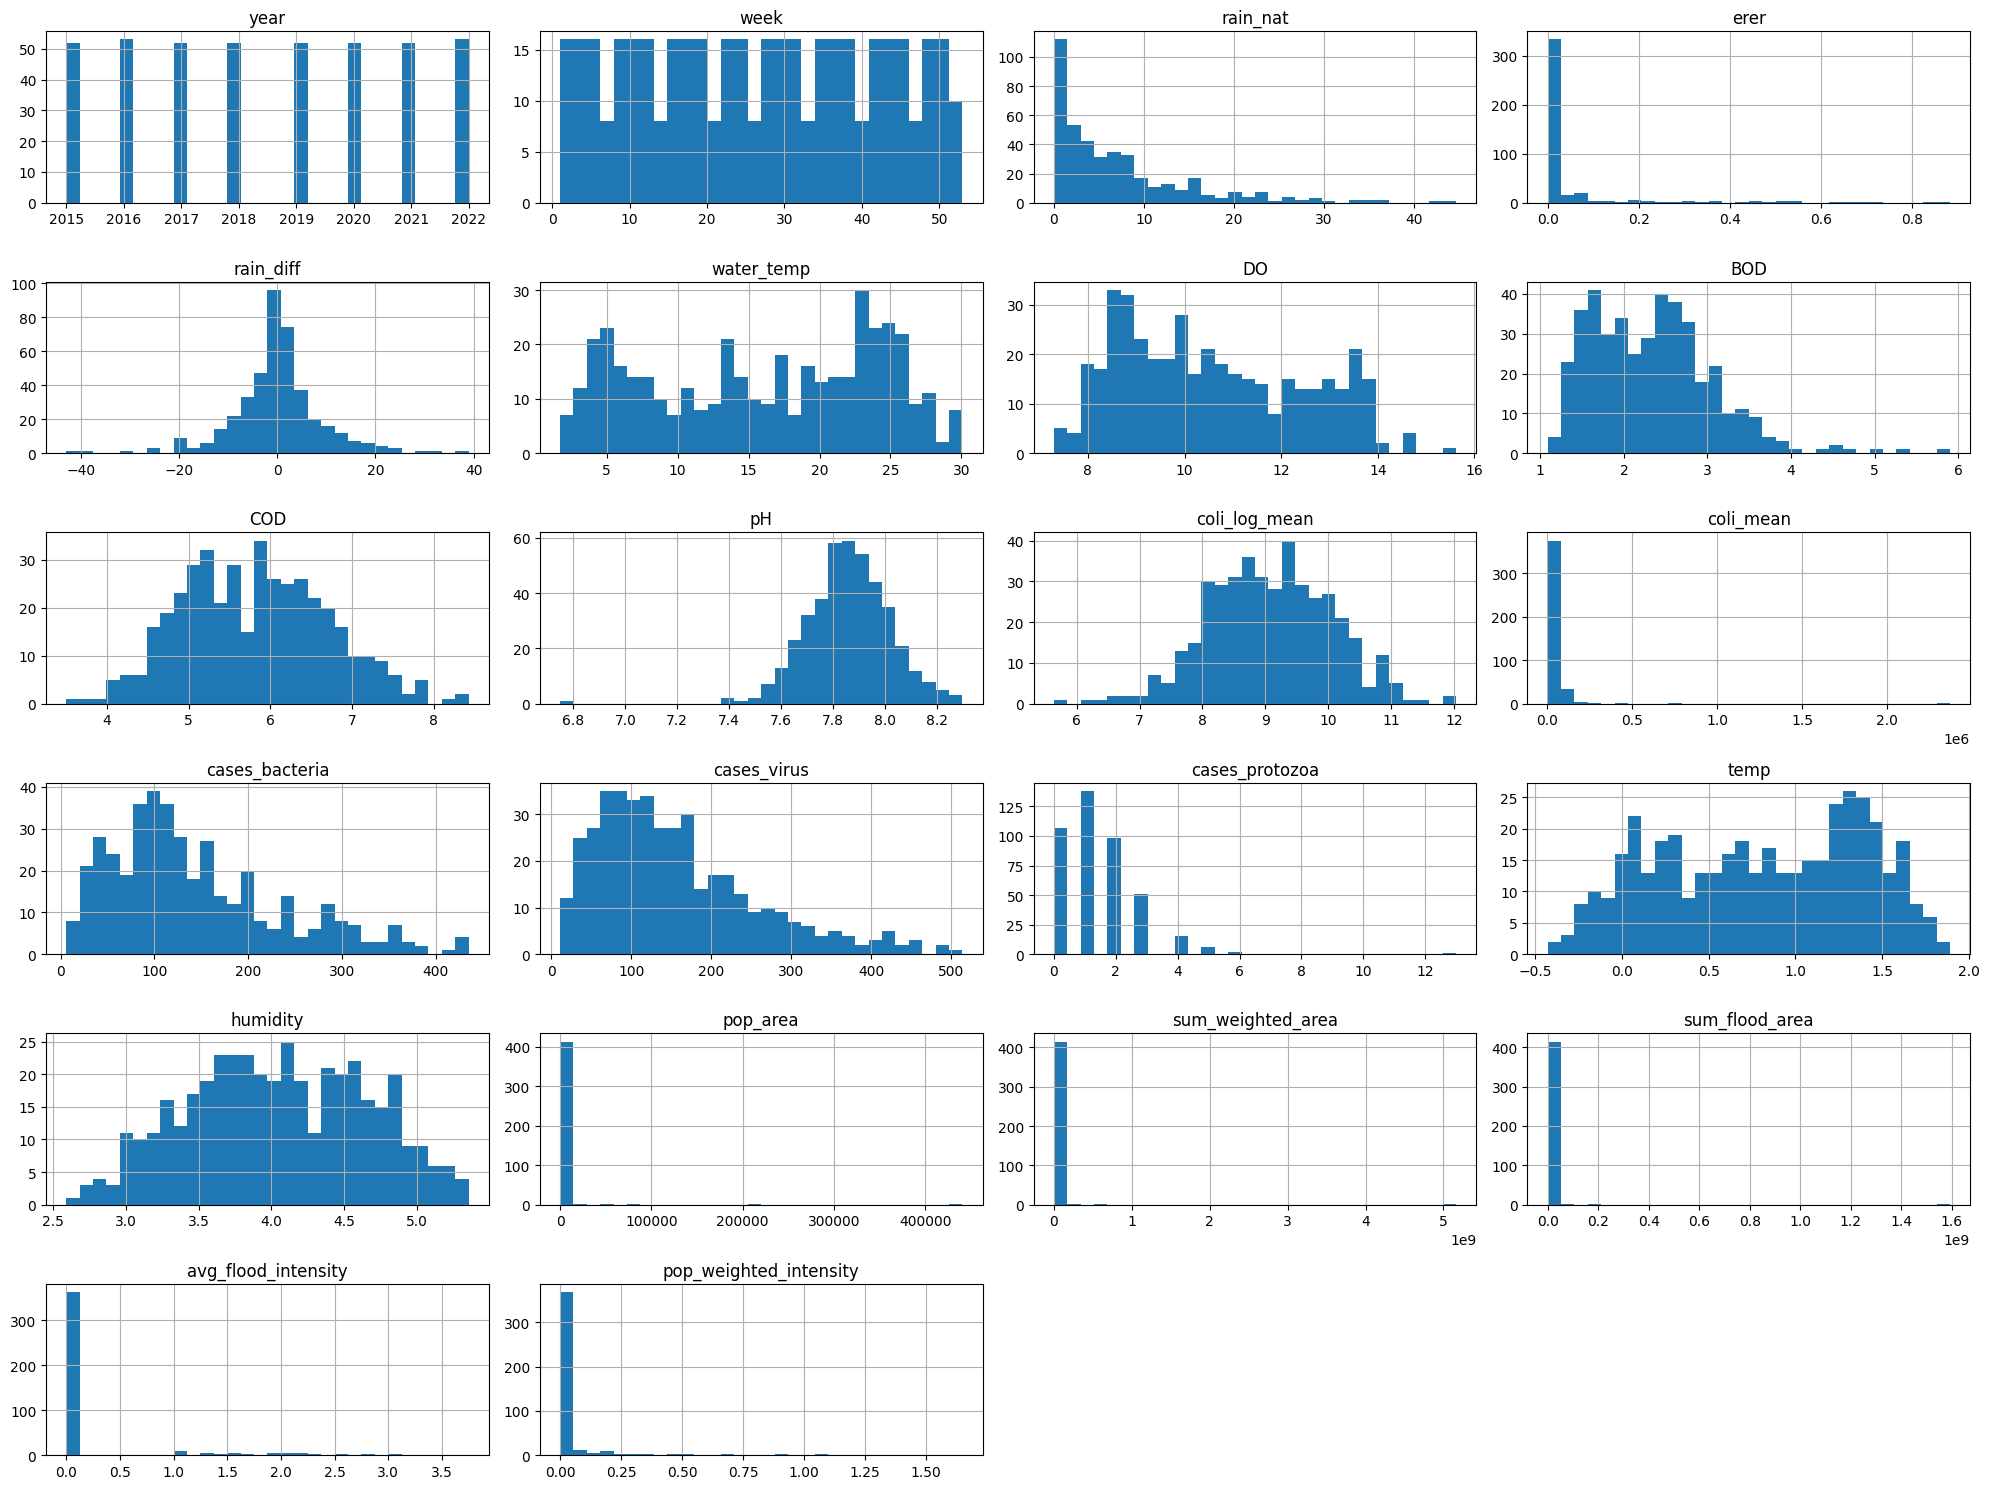

In [ ]:
#분포 확인
import matplotlib.pyplot as plt


df_0[num_cols].hist(
    bins=30,
    figsize=(20,15),
    layout=(int(len(num_cols)/4)+1, 4)
)

plt.tight_layout()
plt.show()


In [ ]:
#왜도 확인
skew_table = pd.DataFrame({
    'skewness': df_0[num_cols].skew(),
    'abs_skewness': df_0[num_cols].skew().abs()
}).sort_values('abs_skewness', ascending=False)

skew_table

#target 변수 왜도 무난

,skewness,abs_skewness
sum_weighted_area,19.939518,19.939518
sum_flood_area,19.845167,19.845167
pop_area,15.733144,15.733144
coli_mean,15.584221,15.584221
pop_weighted_intensity,5.212868,5.212868
erer,3.566662,3.566662
avg_flood_intensity,2.781986,2.781986
cases_protozoa,2.121021,2.121021
rain_nat,1.821782,1.821782
cases_virus,1.088584,1.088584


In [ ]:
#0값 개수 확인
zero_count = (df_0[num_cols] == 0).sum().sort_values(ascending=False)

zero_ratio = ((df_0[num_cols] == 0).sum() / len(df_0)).sort_values(ascending=False)

pd.DataFrame({
    'zero_count': zero_count,
    'zero_ratio': zero_ratio
})

#침수흔적도데이터는 비가 많이 온 것뿐 아니라, 그로 인해 발생한 물리적인 침수 피해를 기록.
#비가 많이 내려도 물이 고이지 않은 경우, 물이 고이더라도 금방 빠져나가 흔적이 남지 않은 경우는 기록이 되지 않음.
#이로 인해 0값이 많이 발생하는 데이터임.

#데이터의 특성상 변환을 하는 것보다는 그대로 사용하는 것이 좋을듯,(0의 의미 보전 위해) or 변수 범주화/이진화
#대신 robustscaler 통해서 보완, tree모델은 로그 변환 필요 없음.

,zero_count,zero_ratio
sum_flood_area,362,0.866029
pop_area,362,0.866029
pop_weighted_intensity,362,0.866029
avg_flood_intensity,362,0.866029
sum_weighted_area,362,0.866029
erer,319,0.763158
cases_protozoa,107,0.255981
rain_nat,1,0.002392
year,0,0.000000
week,0,0.000000


In [ ]:
df_0['cases_protozoa'].value_counts()

#생각보다는 0 값 개수가 많지는 않음.
#값의 종류가 많지 않아서 범주화하는 것 고려. 혹은 hurdle model 고려.
#hurdle model: 발생하느냐 마느냐를 먼저 가르고, 발생하면 몇건이냐 를 예측하는 구조.

,count
cases_protozoa,
1,138
0,107
2,98
3,51
4,15
5,6
6,2
13,1


In [ ]:
df_0[df_0['cases_protozoa']== 13]

,year,week,rain_nat,erer,rain_diff,water_temp,DO,BOD,COD,pH,...,cases_bacteria,cases_virus,cases_protozoa,temp,humidity,pop_area,sum_weighted_area,sum_flood_area,avg_flood_intensity,pop_weighted_intensity
8,2015,9.0,2.63891,0.0,-1.348473,6.228483,13.091166,2.481101,5.165907,7.780124,...,24,166,13,0.188855,3.527977,0.0,0.0,0.0,0.0,0.0


In [ ]:
#결측치 확인
df_0.isnull().sum()

,0
year,0
week,0
rain_nat,0
erer,0
rain_diff,0
water_temp,0
DO,0
BOD,0
COD,0
pH,0


In [ ]:
#세균성감염병, 원충성감염병 분리

df_bac=df_0.copy()
df_bac=df_bac.drop(columns=['cases_virus','cases_protozoa'])

df_pro=df_0.copy()
df_pro=df_pro.drop(columns=['cases_bacteria','cases_virus'])

df_virus=df_0.copy()
df_virus=df_virus.drop(columns=['cases_bacteria','cases_protozoa'])

# **2-1. 세균성감염병 분석**

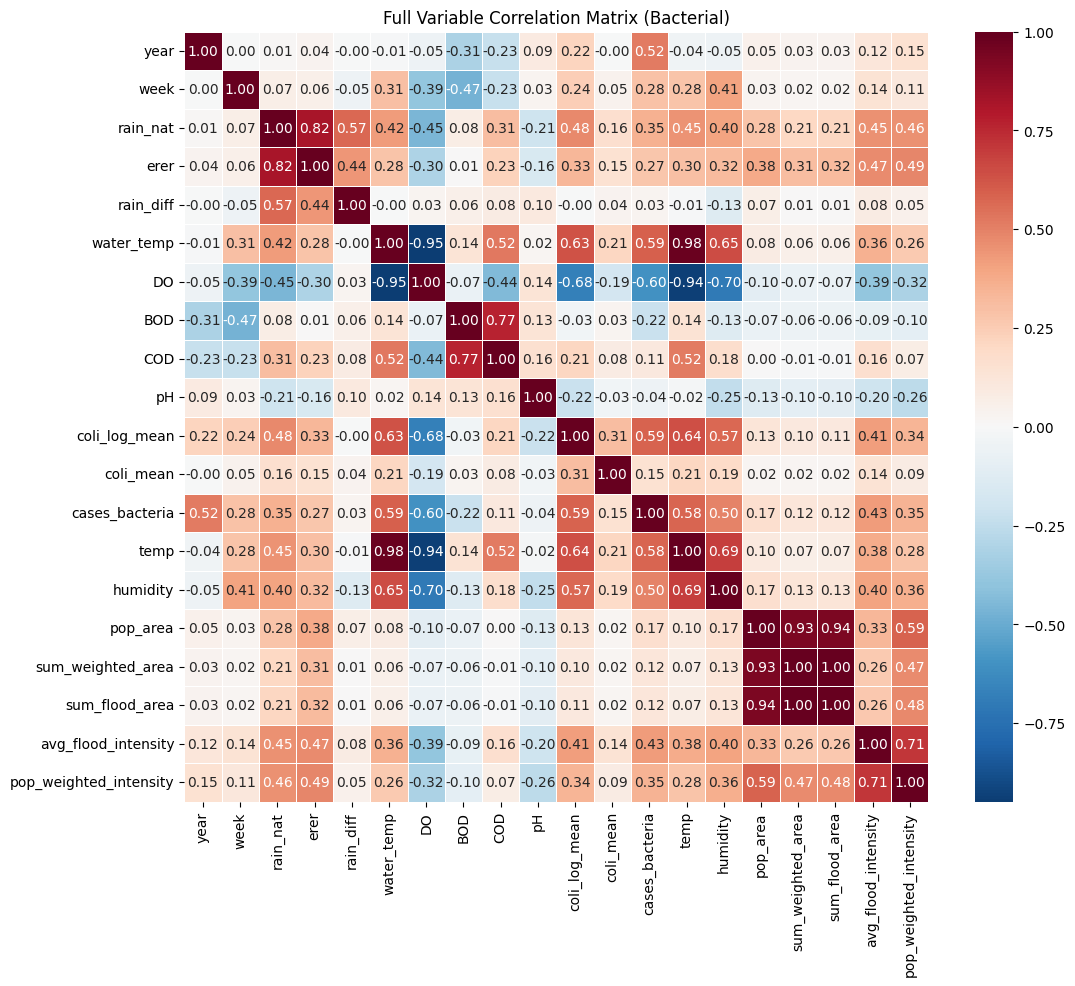

In [ ]:
#상관행렬
import seaborn as sns
import matplotlib.pyplot as plt

# 수치형 변수 전체 선택
all_numeric_cols = df_bac.select_dtypes(include=['number']).columns.tolist()

plt.figure(figsize=(12, 10))
corr_matrix = df_bac[all_numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Full Variable Correlation Matrix (Bacterial)')
plt.show()

#타겟변수와도 양호한 상관관계 나타남

#temp변수가 준기님, 서현님 두번에 걸쳐 수집됨. 서현님 데이터만 남김
#pop_area가 sum_weighted_area 이용 계산되므로, 상관관계 높을 수밖에 없음. 추후에 선형 모델 가용하게 되면 pop_area삭제
#temp와 DO 높은 상관관계. 이로 인해 이차 모델링이 좋을수도(강수조건-수질 지표 1차 모델링, 수질지표-수인성 질병 2차 모델링)
#rain_nat와 ERER도 아마 계산에 이용돼서 상관관계 높게.

#선형 모델 사용시 pop_area, rain_nat/ERER 삭제

In [ ]:
#VIF 계산
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

current_numeric_cols = df_bac.select_dtypes(include=['number']).columns.tolist()
candidate_exclude = ['cases_bacteria', 'month', 'year']


features = [col for col in current_numeric_cols if col not in candidate_exclude]


vif_df = df_bac[features].fillna(0)
vif_result = pd.DataFrame()
vif_result["feature"] = features
vif_result["VIF"] = [variance_inflation_factor(vif_df.values, i) for i in range(len(vif_df.columns))]

print("### VIF 결과 ###")
display(vif_result.sort_values(by="VIF", ascending=False))

#수질 지표들이 VIF가 높이는 주범으로 나옴..
#만약에 선형 모델 사용 시에 VIF높이는 애들 몇개 없애거나 2차 모델링을 하는 것이 좋을듯.
#기온/강수/습도 -> 수질지표 -> 수인성질병

#한편 ph는 target 변수와의 상관관계가 낮은데 vif값이 매우 높게 나와서 없애도 괜찮을듯.

### VIF 결과 ###


,feature,VIF
15,sum_flood_area,4739.045309
14,sum_weighted_area,4597.142641
8,pH,1435.914609
5,DO,558.196436
4,water_temp,238.590637
7,COD,211.940086
9,coli_log_mean,179.455124
12,humidity,118.914272
11,temp,116.058716
6,BOD,43.773354


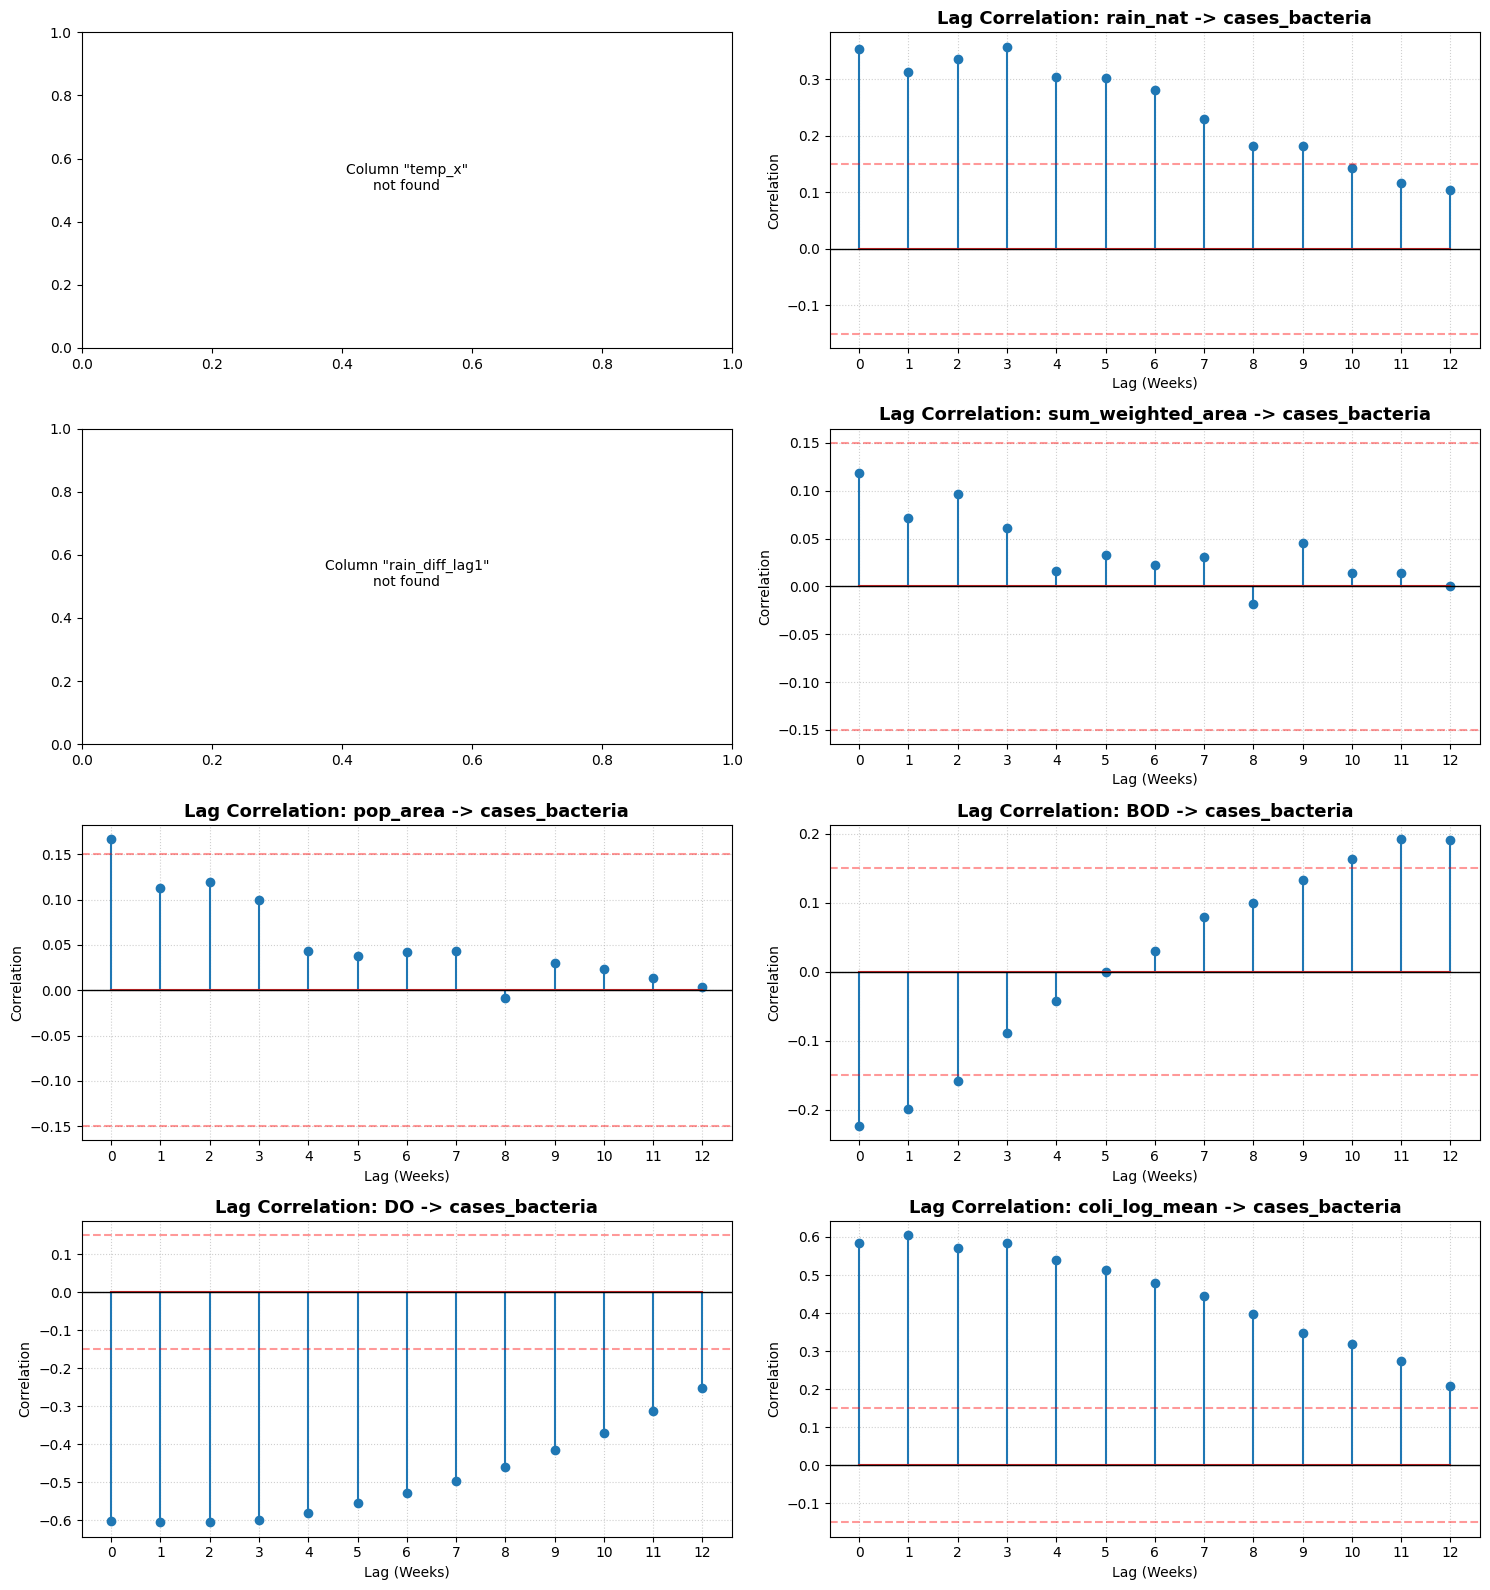

In [ ]:
#지연상관, ccf 계산

import statsmodels.api as sm
import matplotlib.pyplot as plt
import math

def plot_all_ccf_grid(df, target, predictors, lags=12):
    # 1. 그리드 레이아웃 설정 (2열 구성)
    n_plots = len(predictors)
    n_cols = 2
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten() #

    for i, col in enumerate(predictors):
        # 데이터프레임 존재 여부 확인
        if col not in df.columns:
            axes[i].text(0.5, 0.5, f'Column "{col}"\nnot found', ha='center')
            continue

        # 결측치 제외 처리
        valid_data = df[[target, col]].dropna()

        if len(valid_data) < lags:
            axes[i].text(0.5, 0.5, f'Not enough data\nfor "{col}"', ha='center')
            continue

        # CCF 계산
        ccf_values = sm.tsa.stattools.ccf(valid_data[target], valid_data[col], adjusted=False)[:lags+1]

        # 시각화 (Stem Plot)
        axes[i].stem(range(len(ccf_values)), ccf_values)
        axes[i].axhline(y=0.15, color='r', linestyle='--', alpha=0.4)
        axes[i].axhline(y=-0.15, color='r', linestyle='--', alpha=0.4)
        axes[i].axhline(y=0, color='black', linewidth=1)

        # 스타일 설정
        axes[i].set_title(f'Lag Correlation: {col} -> {target}', fontsize=13, fontweight='bold')
        axes[i].set_ylabel('Correlation')
        axes[i].set_xlabel('Lag (Weeks)')
        axes[i].set_xticks(range(0, lags+1))
        axes[i].grid(True, linestyle=':', alpha=0.6) # 그리드 추가로 가독성 향상

    # 사용하지 않는 빈 서브플롯 제거
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# 분석할 최종 독립변수 리스트
final_predictors = [
    'temp_x', 'rain_nat', 'rain_diff_lag1',
    'sum_weighted_area', 'pop_area',
    'BOD', 'DO', 'coli_log_mean'
]

# 실행
plot_all_ccf_grid(df_bac, 'cases_bacteria', final_predictors)

#기온은 Lag1,2
#강수량은 Lag 0
#rain_diff_lag, sum_weighted_area 단독 영향력은 떨어짐
#pop_area lag_0(비교적 높은 상관관계)
#BOD lag 0 (비교적 높은 상관관계)
#DO lag0-3 (매우 높은 상관관계)
#coli_log_mean lag1(매우 높은 상관관계)

KeyError: 'temp_x'

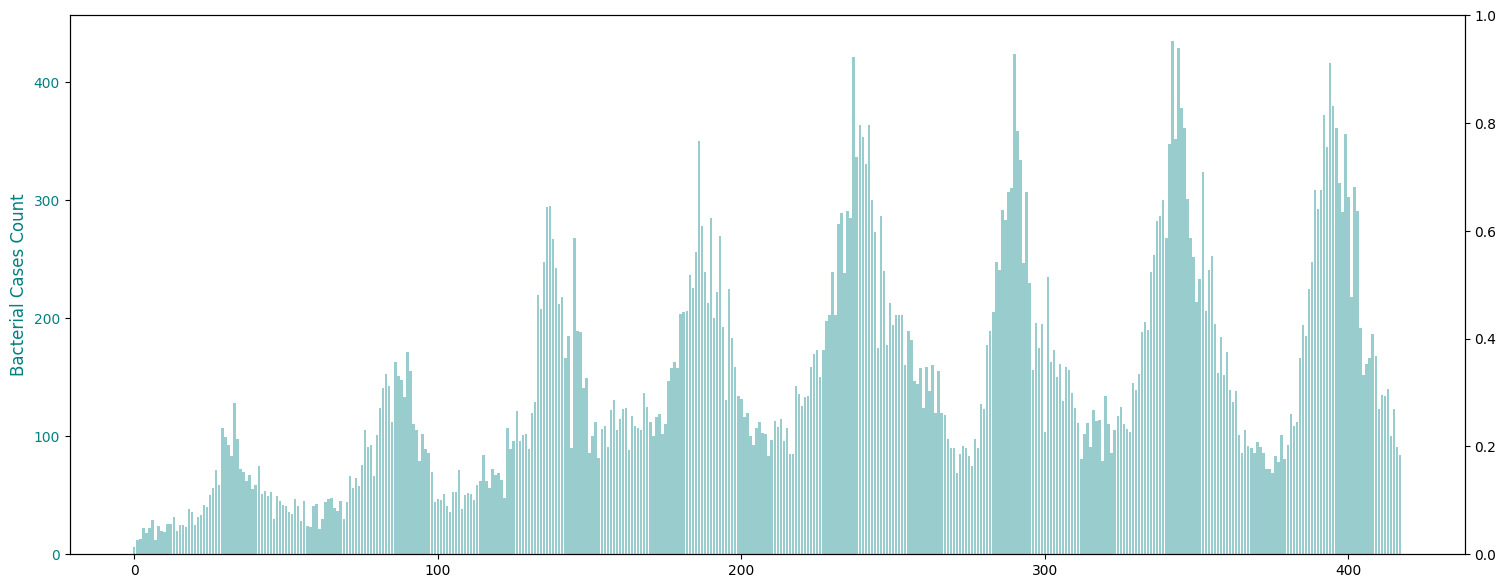

In [ ]:
#다중축 시계열 그래프

fig, ax1 = plt.subplots(figsize=(18, 7))

# X축 설정을 위해 인덱스 활용 (정렬된 데이터 기준)
x_axis = range(len(df_bac))

# 1. 세균성 질병 건수 (Bar)
ax1.bar(x_axis, df_bac['cases_bacteria'], color='teal', alpha=0.4, label='Bacterial Cases')
ax1.set_ylabel('Bacterial Cases Count', color='teal', fontsize=12)
ax1.tick_params(axis='y', labelcolor='teal')

# 2. 평균 기온 (Line) - 두 번째 축
ax2 = ax1.twinx()
ax2.plot(x_axis, df_bac['temp_x'], color='orangered', linewidth=2, label='Avg Temp')
ax2.set_ylabel('Temperature (°C)', color='orangered', fontsize=12)
ax2.tick_params(axis='y', labelcolor='orangered')

# 3. 강수량 (Line) - 세 번째 축 (선택 사항, 필요 시 추가 가능)
# 여기서는 기온과의 관계가 가장 중요해 보여 기온 위주로 구성했습니다.

plt.title('Weekly Bacterial Cases vs Temperature Trend (Full Period)', fontsize=15)
ax1.set_xlabel('Timeline (Index)', fontsize=12)
fig.tight_layout()
plt.show()

#기온에 미세한 시차 존재
#세균성 질병 기온에 극도로 민감.

In [ ]:
#계절성 확인

import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. 계절성 분해 (주기성 52주 설정)
result = seasonal_decompose(df_bac['cases_bacteria'], model='additive', period=52)

# 2. 시각화
plt.rcParams['figure.figsize'] = [12, 10]
result.plot()
plt.show()

#확실한 계절성이 확인됨.더불어 계절성 지표가 일정.  계절성 지표 추가 필요.
#trend가 지속적으로 증가. 즉 단순한 계절성 외에도 인구 변화나 환경 오염의 누적과 같은 장기적인 요인이 작용하고 있음을 시사.
#잔차 크게 튀는 부분들 존재. 추후 모델로 설명 필요. 더불어 잔차에 패턴이 있음.

#trend를 모델에 반영하는 것도 괜찮을듯.

NameError: name 'df_bac' is not defined

In [ ]:
import pandas as pd
import numpy as np

# 1. 'week' 컬럼이 인덱스에 있다면 꺼내오고, 이미 컬럼으로 있다면 그대로 사용합니다.
if 'week' not in df_bac.columns:
    df_bac['week'] = df_bac.index.astype(int)

# 2. Week 기반 Month 추정 (1~52주를 1~12월로 매핑)
# 간단하게 (week-1) // 4.35 + 1 공식을 사용하거나 구간을 직접 나눕니다.
def week_to_month(week):
    if week <= 4: return 1
    elif week <= 8: return 2
    elif week <= 13: return 3
    elif week <= 17: return 4
    elif week <= 21: return 5
    elif week <= 26: return 6
    elif week <= 30: return 7
    elif week <= 35: return 8
    elif week <= 39: return 9
    elif week <= 43: return 10
    elif week <= 48: return 11
    else: return 12

df_bac['month'] = df_bac['week'].apply(week_to_month)

# 3. 여름(Summer) 정의 (26주~35주차 정도가 보통 6~8월 피크입니다)
# 위에서 만든 month를 써도 되고, week로 직접 지정해도 됩니다.
df_bac['is_summer'] = df_bac['month'].apply(lambda x: 1 if x in [6, 7, 8, 9] else 0)

# 4. 사계절 원핫 인코딩
def get_season(month):
    if month in [3, 4, 5]: return 'spring'
    elif month in [6, 7, 8]: return 'summer'
    elif month in [9, 10, 11]: return 'fall'
    else: return 'winter'

df_bac['season_name'] = df_bac['month'].apply(get_season)
df_bac = pd.get_dummies(df_bac, columns=['season_name'], prefix='season')

# 5. 주기성(Cyclic) 변수 추가 (1~52 순환 고려)
df_bac['week_sin'] = np.sin(2 * np.pi * df_bac['week'] / 52)
df_bac['week_cos'] = np.cos(2 * np.pi * df_bac['week'] / 52)

print("### Week 기반 계절 변수 생성 완료 ###")
print(df_bac[['week', 'month', 'is_summer', 'season_summer']].head())

In [ ]:
df_bac.head()

In [ ]:
df_bac=df_bac.drop(columns=['is_summer'])

In [ ]:
df_bac.head()

#week_sin, week_cos: 주기성변수

In [ ]:
#추세(trend) 반영 변수 생성
df_bac['time_step'] = range(len(df_bac))

In [ ]:
# 음이항 회귀 모델링
#사실 lag을 주고 계산하는 게 더 정확하긴 할듯
#아직 결과 해석은 못함.


import statsmodels.api as sm
import statsmodels.formula.api as smf

#데이터 준비
df_model = df_bac.copy()

#formula 정의
formula = """
cases_bacteria ~ temp_x + rain_nat + coli_log_mean + pop_area +
                 time_step + season_spring + season_summer + season_fall +
                 week_sin + week_cos
"""

#음이항 GLM 적합 (log link 기본)
nb_model = smf.glm(
    formula=formula,
    data=df_model,
    family=sm.families.NegativeBinomial(link=sm.families.links.log())
).fit()

#결과 출력
print(nb_model.summary())


In [ ]:
df_bac.to_excel('df_bac.xlsx')
from google.colab import files
files.download('df_bac.xlsx')

# **2-2.원충성질병분석**

In [ ]:
#상관행렬
import seaborn as sns
import matplotlib.pyplot as plt

# 수치형 변수 전체 선택
all_numeric_cols = df_pro.select_dtypes(include=['number']).columns.tolist()

plt.figure(figsize=(12, 10))
corr_matrix = df_pro[all_numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Full Variable Correlation Matrix (Bacterial)')
plt.show()

#모든 변수들의 원충성 질병에 대한 상관관계가 매우 낮게 나타남.
#이는 원충성 질병이 뒤늦게 나타나는 질병인 것 + 빈도가 낮게 나타는 변수임이 함께 나탄나는 결과로 판단됨.

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import math
import numpy as np

def plot_all_ccf_grid(df, target, predictors, lags=16): # lags를 16으로 확장 추천
    # 1. 그리드 레이아웃 설정
    n_plots = len(predictors)
    n_cols = 2
    n_rows = math.ceil(n_plots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()

    # 신뢰구간 계산 (약 95% 신뢰수준: 1.96 / sqrt(N))
    n_obs = len(df.dropna(subset=[target]))
    conf_level = 1.96 / np.sqrt(n_obs)

    for i, col in enumerate(predictors):
        # 컬럼 존재 여부 확인
        if col not in df.columns:
            axes[i].text(0.5, 0.5, f'Column "{col}"\nnot found', ha='center')
            continue

        # 결측치 제외 처리 (Target과 Predictor 쌍으로 제거)
        valid_data = df[[target, col]].dropna()

        if len(valid_data) < lags:
            axes[i].text(0.5, 0.5, f'Not enough data\nfor "{col}"', ha='center')
            continue

        # CCF 계산 (상관관계 수치 추출)
        # adjusted=False는 샘플 수가 충분할 때 표준적으로 사용됩니다.
        ccf_values = sm.tsa.stattools.ccf(valid_data[target], valid_data[col], adjusted=False)[:lags+1]

        # 시각화 (Stem Plot)
        axes[i].stem(range(len(ccf_values)), ccf_values)

        # 유의미한 상관관계 기준선 (빨간 점선)
        axes[i].axhline(y=conf_level, color='r', linestyle='--', alpha=0.5, label='Significance')
        axes[i].axhline(y=-conf_level, color='r', linestyle='--', alpha=0.5)
        axes[i].axhline(y=0, color='black', linewidth=1)

        # 스타일 설정
        axes[i].set_title(f'Lag Correlation: {col} -> {target}', fontsize=13, fontweight='bold')
        axes[i].set_ylabel('Correlation')
        axes[i].set_xlabel('Lag (Weeks)')
        axes[i].set_xticks(range(0, lags+1, 2)) # 가독성을 위해 2주 단위 표시
        axes[i].grid(True, linestyle=':', alpha=0.6)

    # 빈 서브플롯 제거
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# --- 실행부 ---
# 분석할 독립변수 리스트 (기상, 침수, 수질)
final_predictors = [
    'temp_x', 'rain_nat', 'rain_diff_lag1',
    'sum_weighted_area', 'pop_area',
    'BOD', 'DO', 'coli_log_mean'
]

# 타겟 변수명을 데이터프레임 실제 이름에 맞춰 확인하세요 (protozoa vs protoza)
target_column = 'cases_protozoa'

plot_all_ccf_grid(df_pro, target_column, final_predictors, lags=16)


#아래의 ccf, 지연 상관을 분석했을 때도 크게 유의미한 변수가 많지 않음.
#더불어 원충성질병은 정기적으로 발생하는 것이 아니라, 특정 기상이변에 의해 간헐적으로 폭발함.
#전반적으로 lag10이 적절한 지연으로 판단됨.

In [ ]:
#계절성 확인

import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. 계절성 분해 (주기성 52주 설정)
result = seasonal_decompose(df_pro['cases_protozoa'], model='additive', period=52)

# 2. 시각화
plt.rcParams['figure.figsize'] = [12, 10]
result.plot()
plt.show()

#세균성질병과 달리 데이터에 특별한 계절적 특징이 나타나지않음.
#정기적인 추세라기 보다는 간헐적인 폭발이 이루어진다고 분석하는 것이 타당함.
#따라서 protozoa에 대해서는 계절성 지표 추가하지 않음.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. 원본 데이터 복사
df_pro_model = df_pro.copy()

# 2. CCF 결과를 바탕으로 주요 피처들에 Lag 10(10주 전) 적용
lag_cols = ['temp_x', 'rain_nat', 'sum_weighted_area', 'coli_log_mean', 'BOD', 'pop_area']

for col in lag_cols:
    df_pro_model[f'{col}_lag10'] = df_pro_model[col].shift(10)

# 3. 추세(Trend) 변수 생성 및 결측치 제거
# STL 분해에서 보인 장기적인 흐름을 반영하기 위해 time_step을 포함합니다.
df_pro_model['time_step'] = np.arange(len(df_pro_model))
df_pro_final = df_pro_model.dropna()

In [ ]:
# 4. 모델 수식 정의 (계절성 변수 제외)
formula_pro_final = """cases_protozoa ~ temp_x_lag10 + rain_nat_lag10 +
                        sum_weighted_area_lag10 + coli_log_mean_lag10 +
                        BOD_lag10 + pop_area_lag10 + time_step"""

# 5. 음이항 회귀 적합
# 과분산이 큰 원충 데이터 특성을 고려하여 Negative Binomial을 사용합니다.
nb_pro_res = smf.glm(formula=formula_pro_final,
                     data=df_pro_final,
                     family=sm.families.NegativeBinomial()).fit()

# 6. 결과 요약 출력
print(nb_pro_res.summary())

# **2-3. 바이러스성 질병 분석**

**0) 바이러스 case 및 경향성 분석**

In [ ]:
#+ 온도에 따른 바이러스 case 경향성 분석 필요할듯

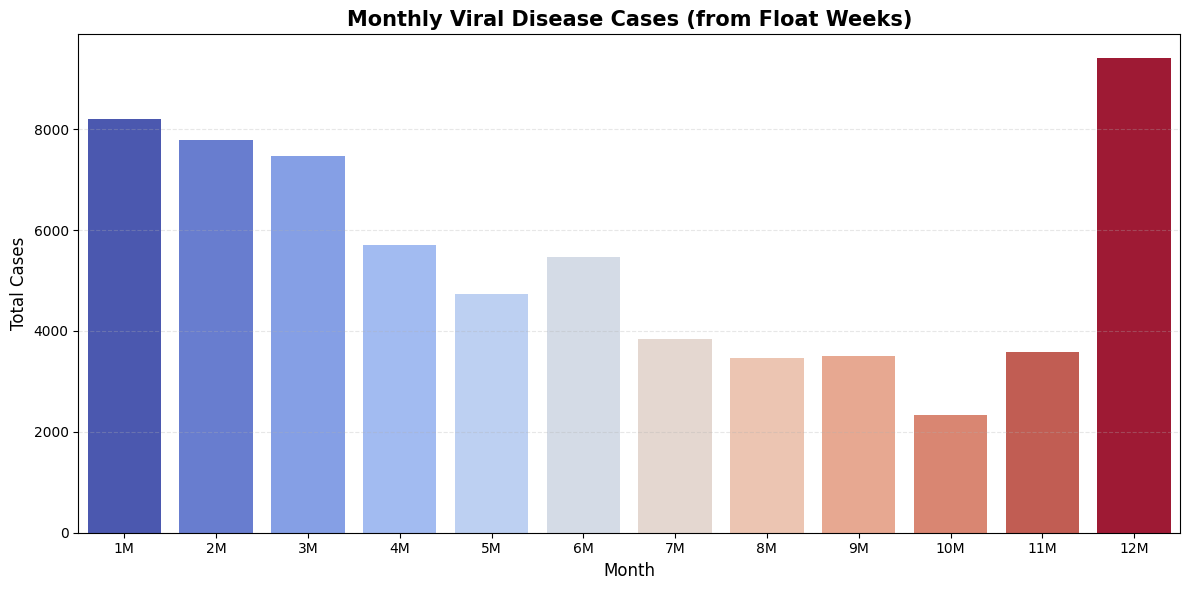

In [ ]:
#계절별 바이러스 추세

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Week(float) -> Month(int) 매핑 함수
def map_week_to_month(w):
    # float인 경우를 대비해 정수로 변환 (예: 1.0 -> 1)
    w_int = int(w)

    if w_int <= 4: return 1
    elif w_int <= 8: return 2
    elif w_int <= 13: return 3
    elif w_int <= 17: return 4
    elif w_int <= 21: return 5
    elif w_int <= 26: return 6
    elif w_int <= 30: return 7
    elif w_int <= 34: return 8
    elif w_int <= 39: return 9
    elif w_int <= 43: return 10
    elif w_int <= 47: return 11
    else: return 12

# 2. 'month' 변수 생성 (apply 사용)
df_virus['month'] = df_virus['week'].apply(map_week_to_month)

# 3. 시각화: 월별 총 확진자 수
plt.figure(figsize=(12, 6))
sns.barplot(data=df_virus, x='month', y='cases_virus',
            estimator=sum, errorbar=None, palette='coolwarm', hue='month', legend=False)

plt.title('Monthly Viral Disease Cases (from Float Weeks)', fontsize=15, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Cases', fontsize=12)

# x축 레이블을 1월~12월로 표시
plt.xticks(ticks=range(0, 12), labels=[f'{i}M' for i in range(1, 13)])
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

#아래의 그래프를 통해 겨울에 발생 빈도가 높은 것은 사실이나, 여름에도 발생
#우리가 보고자하는 것은 여름철 강수/폭우가 이러한 발생 빈도에 어떤 영향을 주는지 보고자하는 것임.

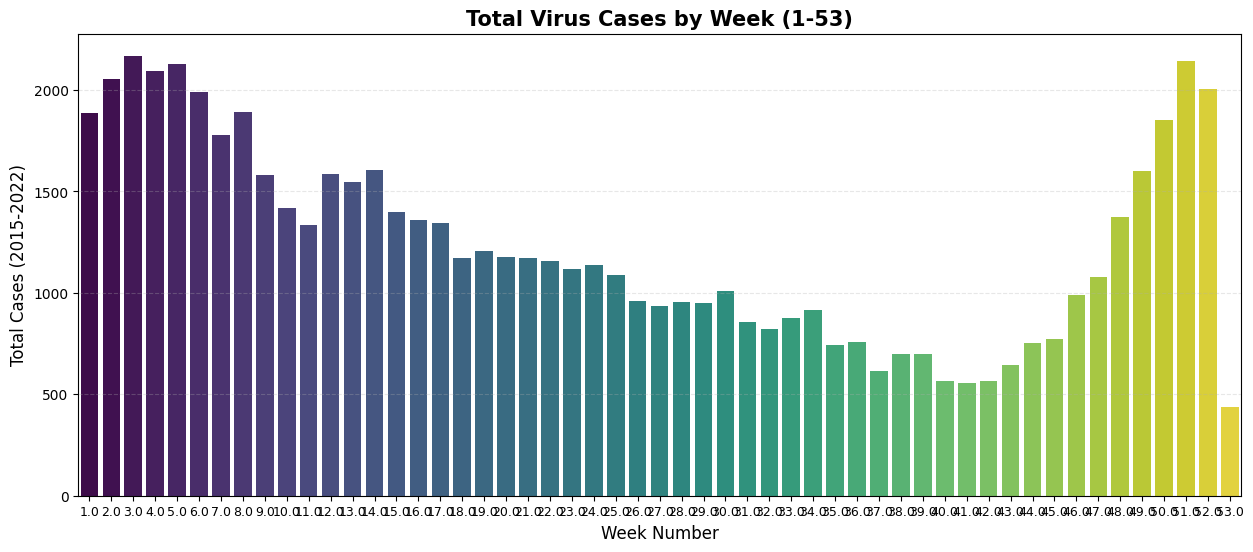

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 크기 설정
plt.figure(figsize=(15, 6))

# x='week'가 숫자이므로, 이를 기반으로 cases_virus의 합계를 구함
# ci=None은 오차 범위를 표시하지 않아 속도가 빠르고 깔끔합니다.
sns.barplot(data=df_virus, x='week', y='cases_virus', estimator=sum, errorbar=None, palette='viridis', hue='week', legend=False)

# 그래프 가독성 높이기
plt.title('Total Virus Cases by Week (1-53)', fontsize=15, fontweight='bold')
plt.xlabel('Week Number', fontsize=12)
plt.ylabel('Total Cases (2015-2022)', fontsize=12)

# x축 눈금이 너무 많으면 겹칠 수 있으니 5단위로 표시하거나 폰트를 조절합니다.
plt.xticks(fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

**1) 상관관계분석**

In [ ]:
df_virus=df_virus.drop(columns=['avg_flood_intensity','sum_flood_area'])

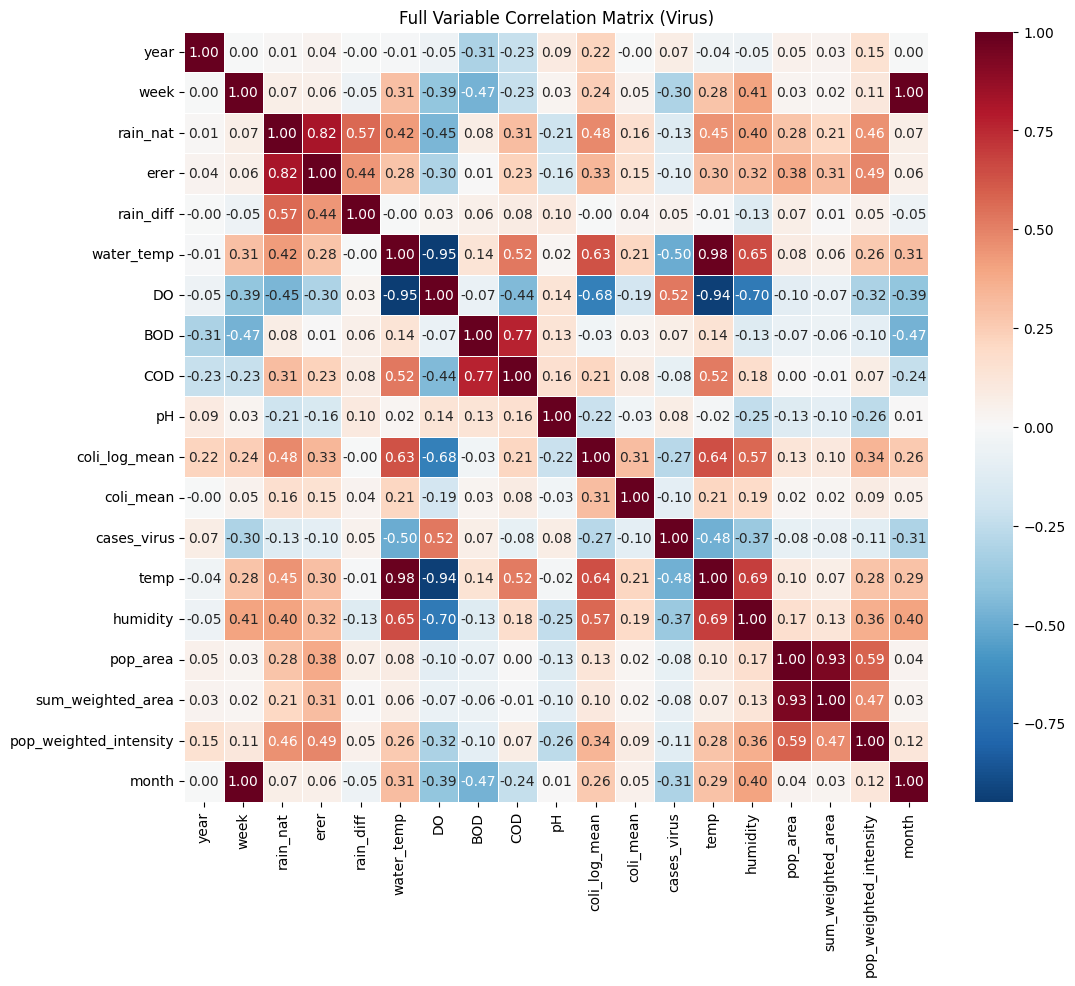

In [ ]:
#상관행렬
import seaborn as sns
import matplotlib.pyplot as plt

# 수치형 변수 전체 선택
all_numeric_cols = df_virus.select_dtypes(include=['number']).columns.tolist()

plt.figure(figsize=(12, 10))
corr_matrix = df_virus[all_numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Full Variable Correlation Matrix (Virus)')
plt.show()

#cases_virus에 대해 전반적인 피처들의 낮은 상관관계가 보임.

In [ ]:
import pandas as pd
import numpy as np

# 1. 숫자형 변수만 선택
df_num = df_virus.select_dtypes(include=[np.number])

# 2. 상관행렬 계산
corr_matrix = df_num.corr(method='pearson')

# 3. 상삼각행렬만 추출 (중복 제거)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# 4. 상관계수 절대값 기준 설정 (예: 0.7 이상)
threshold = 0.7

high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={
             'level_0': 'Variable_1',
             'level_1': 'Variable_2',
             0: 'Correlation'
         })
)

# 5. 기준 이상만 필터링
high_corr_pairs = high_corr_pairs[
    high_corr_pairs['Correlation'].abs() >= threshold
].sort_values(by='Correlation', key=lambda x: abs(x), ascending=False)

high_corr_pairs


,Variable_1,Variable_2,Correlation
34,week,month,0.996498
87,water_temp,temp,0.983654
80,water_temp,DO,-0.948671
99,DO,temp,-0.941001
165,pop_area,sum_weighted_area,0.933437
35,rain_nat,erer,0.819143
105,BOD,COD,0.769155


In [ ]:
target_corr = corr_matrix['cases_virus'].drop('cases_virus')

target_corr_high = (
    target_corr
    .reset_index()
    .rename(columns={
        'index': 'Variable',
        'cases_virus': 'Correlation'
    })
)

# 기준 설정 (예: |r| ≥ 0.3)
threshold_target = 0.3

target_corr_high = target_corr_high[
    target_corr_high['Correlation'].abs() >= threshold_target
].sort_values(by='Correlation', key=lambda x: abs(x), ascending=False)

target_corr_high


,Variable,Correlation
6,DO,0.522607
5,water_temp,-0.497079
12,temp,-0.477618
13,humidity,-0.368241
17,month,-0.307223
1,week,-0.302530


**1) 상관관계분석- 지연상관**

In [ ]:
#ccf 계산

import numpy as np
import pandas as pd
from scipy.stats import pearsonr

def compute_ccf(df, x_var, y_var='cases_virus', max_lag=8):
    """
    x_var가 먼저 발생 → y_var가 나중에 발생하는 구조
    lag > 0 : x가 l주 먼저 움직임
    """
    results = []

    for lag in range(0, max_lag+1):
        x_shifted = df[x_var].shift(lag)
        valid = df[[y_var]].copy()
        valid[x_var] = x_shifted
        valid = valid.dropna()

        if len(valid) > 10:
            r, p = pearsonr(valid[x_var], valid[y_var])
            results.append((lag, r, p))

    result_df = pd.DataFrame(results, columns=['lag', 'correlation', 'p_value'])
    result_df['abs_corr'] = result_df['correlation'].abs()
    result_df = result_df.sort_values('abs_corr', ascending=False)

    return result_df
variables = [
    'rain_nat',
    'rain_diff',
    'temp',
    'humidity',
    'sum_weighted_area',
    'pop_weighted_intensity',
    'DO',
    'coli_log_mean',
    'cases_virus'   # 자기상관 확인용
]

ccf_results = {}
ccf_best_summary = []

for var in variables:
    ccf_table = compute_ccf(df_virus, var, max_lag=8)
    ccf_results[var] = ccf_table

    if len(ccf_table) > 0:
        best = ccf_table.iloc[0]
        ccf_best_summary.append({
            'variable': var,
            'best_lag': best['lag'],
            'correlation': best['correlation'],
            'p_value': best['p_value']
        })

ccf_summary_df = pd.DataFrame(ccf_best_summary)\
                    .sort_values('correlation', key=lambda x: x.abs(), ascending=False)

ccf_summary_df

#예상했던 대부분의 지표들이 음의 상관관계로 나오는 상황.
#온도와 양의 상관관계를 갖는 지표들이 모두 결과적인 음의 상관관계를 나타냄.
#이는 바이러스의 계절적 특징과 온도의 특성으로 인한 것임.
#자기상관 구조 통제 위해 자기회귀 항 추가해야함.

,variable,best_lag,correlation,p_value
8,cases_virus,1.0,1.000000,0.000000e+00
6,DO,1.0,0.542144,3.113686e-33
2,temp,4.0,-0.537642,2.182266e-32
3,humidity,2.0,-0.391861,1.017161e-16
7,coli_log_mean,5.0,-0.321076,2.340643e-11
0,rain_nat,6.0,-0.266377,4.020955e-08
5,pop_weighted_intensity,5.0,-0.198369,4.917108e-05
4,sum_weighted_area,5.0,-0.081757,9.706648e-02
1,rain_diff,0.0,0.047613,3.315031e-01


In [ ]:
compute_ccf(df_virus, 'rain_nat', max_lag=8)

#바이러스는 겨울에 많이 발생, 이로 인해 강수량과 음의 상관관계 -> 바이러스 분석에 무의미.
#따라서 강수량과 바이러스 효과 분석할 때는 온도를 제외하고, 그 잔차를 분석해야함.

,lag,correlation,p_value,abs_corr
6,6,-0.266377,4.020955e-08,0.266377
7,7,-0.258190,1.104358e-07,0.258190
8,8,-0.255340,1.591873e-07,0.255340
5,5,-0.248027,3.304260e-07,0.248027
4,4,-0.229607,2.347887e-06,0.229607
3,3,-0.215105,9.839619e-06,0.215105
2,2,-0.206347,2.217826e-05,0.206347
1,1,-0.189865,9.577422e-05,0.189865
0,0,-0.133805,6.147693e-03,0.133805


In [ ]:
compute_ccf(df_virus, 'rain_diff', max_lag=8)

#강수량 차분은 양의 상관관계, 그러나 좀 더 약함.
#바이러스 건수를 바로 분석할 때는 차분만 넣는 것이 더 좋을듯.
#lag 0이 가장 적절

,lag,correlation,p_value,abs_corr
0,0,0.047613,0.331503,0.047613
5,5,0.017059,0.729605,0.017059
4,4,0.016675,0.735147,0.016675
3,3,0.013405,0.785422,0.013405
1,1,0.012635,0.796990,0.012635
8,8,-0.008098,0.870147,0.008098
6,6,-0.006998,0.887385,0.006998
2,2,0.006809,0.889877,0.006809
7,7,-0.003373,0.945647,0.003373


**2) 온도와 계절성 통제- 음이항 회귀를 통하여 잔차 구조 파악**

In [ ]:
import numpy as np
import pandas as pd

# 주차를 연속형 인덱스로 변환
df_virus = df_virus.sort_values(['year','week']).reset_index(drop=True)
df_virus['t'] = np.arange(len(df_virus))

# 1차 Fourier term (연간 주기)
df_virus['sin52'] = np.sin(2 * np.pi * df_virus['t'] / 52)
df_virus['cos52'] = np.cos(2 * np.pi * df_virus['t'] / 52)

# 필요하면 2차 조화항 추가 가능
df_virus['sin52_2'] = np.sin(4 * np.pi * df_virus['t'] / 52)
df_virus['cos52_2'] = np.cos(4 * np.pi * df_virus['t'] / 52)


#Fourier term 사용

In [ ]:
df_virus.head()

,year,week,rain_nat,erer,rain_diff,water_temp,DO,BOD,COD,pH,...,humidity,pop_area,sum_weighted_area,pop_weighted_intensity,month,t,sin52,cos52,sin52_2,cos52_2
0,2015,1.0,3.772672,0.0,3.772672,1.701246,15.622046,1.936856,3.764894,6.748502,...,3.199137,0.0,0.0,0.0,1,0,0.000000,1.000000,0.000000,1.000000
1,2015,2.0,1.185419,0.0,-2.587254,3.712223,13.466400,2.436846,4.732934,7.682216,...,3.658332,0.0,0.0,0.0,1,1,0.120537,0.992709,0.239316,0.970942
2,2015,3.0,2.691617,0.0,1.506199,3.724155,14.035902,2.379334,4.717393,7.709611,...,3.580605,0.0,0.0,0.0,1,2,0.239316,0.970942,0.464723,0.885456
3,2015,4.0,2.586522,0.0,-0.105095,3.998386,13.746543,1.649368,4.705090,7.859229,...,4.251323,0.0,0.0,0.0,1,3,0.354605,0.935016,0.663123,0.748511
4,2015,5.0,0.509471,0.0,-2.077051,5.263631,13.063065,3.622871,5.704383,7.775275,...,4.068619,0.0,0.0,0.0,2,4,0.464723,0.885456,0.822984,0.568065


In [ ]:
#온도와 계절성 모두 통제

import statsmodels.api as sm
import statsmodels.formula.api as smf

# 모델 수식
formula = """
cases_virus ~ temp + sin52 + cos52 + sin52_2 + cos52_2
"""

nb_model = smf.glm(
    formula=formula,
    data=df_virus,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model.summary())

#변수를 많이 사용하지 않았으므로 R - square 낮은 것 당연함
#한편 아래의 계절성 변수에서 p-vlaue 유의한 값들 존재

#아래 회귀의 가장 중요한 목적은, cases_virus에서 온도와 계절성의 영향력을 통제하는 것임.

                 Generalized Linear Model Regression Results                  
Dep. Variable:            cases_virus   No. Observations:                  418
Model:                            GLM   Df Residuals:                      412
Model Family:        NegativeBinomial   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2503.7
Date:                Sun, 22 Feb 2026   Deviance:                       127.23
Time:                        03:23:38   Pearson chi2:                     130.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1271
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.0181      0.327     15.330      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [ ]:
# deviance residual
df_virus['nb_residual'] = nb_model.resid_deviance

# pearson residual (참고용)
df_virus['nb_residual_pearson'] = nb_model.resid_pearson


In [ ]:
#계절성만 통제

import statsmodels.api as sm
import statsmodels.formula.api as smf

# 모델 수식
formula = """
cases_virus ~ sin52 + cos52 + sin52_2 + cos52_2
"""

nb_model = smf.glm(
    formula=formula,
    data=df_virus,
    family=sm.families.NegativeBinomial()
).fit()

print(nb_model.summary())



                 Generalized Linear Model Regression Results                  
Dep. Variable:            cases_virus   No. Observations:                  418
Model:                            GLM   Df Residuals:                      413
Model Family:        NegativeBinomial   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2503.7
Date:                Sun, 22 Feb 2026   Deviance:                       127.24
Time:                        03:23:42   Pearson chi2:                     130.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1270
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.9836      0.049    101.513      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [ ]:
# deviance residual
df_virus['nb_residual_1'] = nb_model.resid_deviance

# pearson residual (참고용)
df_virus['nb_residual_pearson_1'] = nb_model.resid_pearson


In [ ]:
df_virus.head()

,year,week,rain_nat,erer,rain_diff,water_temp,DO,BOD,COD,pH,...,month,t,sin52,cos52,sin52_2,cos52_2,nb_residual,nb_residual_pearson,nb_residual_1,nb_residual_pearson_1
0,2015,1.0,3.772672,0.0,3.772672,1.701246,15.622046,1.936856,3.764894,6.748502,...,1,0,0.000000,1.000000,0.000000,1.000000,-0.840537,-0.623448,-0.832551,-0.619378
1,2015,2.0,1.185419,0.0,-2.587254,3.712223,13.466400,2.436846,4.732934,7.682216,...,1,1,0.120537,0.992709,0.239316,0.970942,-0.972096,-0.686055,-0.972846,-0.686389
2,2015,3.0,2.691617,0.0,1.506199,3.724155,14.035902,2.379334,4.717393,7.709611,...,1,2,0.239316,0.970942,0.464723,0.885456,-0.704126,-0.549499,-0.707055,-0.551188
3,2015,4.0,2.586522,0.0,-0.105095,3.998386,13.746543,1.649368,4.705090,7.859229,...,1,3,0.354605,0.935016,0.663123,0.748511,-0.251288,-0.230695,-0.257072,-0.235531
4,2015,5.0,0.509471,0.0,-2.077051,5.263631,13.063065,3.622871,5.704383,7.775275,...,2,4,0.464723,0.885456,0.822984,0.568065,-0.280935,-0.255266,-0.282292,-0.256378


**3) 잔차에 대한 나머지 변수들의 분석**

In [ ]:
from scipy.stats import pearsonr
import pandas as pd

def compute_ccf_resid(df, x_var, resid_var='nb_residual', max_lag=8):
    results = []

    for lag in range(0, max_lag+1):
        x_shifted = df[x_var].shift(lag)
        temp = pd.concat([df[resid_var], x_shifted], axis=1).dropna()
        temp.columns = [resid_var, x_var]

        if len(temp) > 10:
            r, p = pearsonr(temp[x_var], temp[resid_var])
            results.append((lag, r, p))

    result_df = pd.DataFrame(results, columns=['lag', 'correlation', 'p_value'])
    result_df['abs_corr'] = result_df['correlation'].abs()
    result_df = result_df.sort_values('abs_corr', ascending=False)

    return result_df

variables = [
    'rain_nat',
    'rain_diff',
    'temp',
    'humidity',
    'sum_weighted_area',
    'pop_weighted_intensity',
    'DO',
    'coli_log_mean'
]

ccf_resid_summary = []

for var in variables:
    ccf_table = compute_ccf_resid(df_virus, var, max_lag=8)

    if len(ccf_table) > 0:
        best = ccf_table.iloc[0]
        ccf_resid_summary.append({
            'variable': var,
            'best_lag': best['lag'],
            'correlation': best['correlation'],
            'p_value': best['p_value']
        })

ccf_resid_summary_df = pd.DataFrame(ccf_resid_summary)\
                          .sort_values('correlation', key=lambda x: x.abs(), ascending=False)

ccf_resid_summary_df

,variable,best_lag,correlation,p_value
4,sum_weighted_area,5.0,-0.127054,0.009746
5,pop_weighted_intensity,8.0,-0.119261,0.015687
3,humidity,1.0,-0.100927,0.039392
6,DO,1.0,0.090729,0.064170
2,temp,3.0,-0.073747,0.133650
7,coli_log_mean,8.0,-0.062108,0.209491
0,rain_nat,6.0,-0.041911,0.396161
1,rain_diff,0.0,0.035493,0.469247


In [ ]:
sum_ccf=compute_ccf_resid(df_virus, 'DO', max_lag=8)
sum_ccf

,lag,correlation,p_value,abs_corr
1,1,0.090729,0.064170,0.090729
4,4,0.090115,0.066987,0.090115
3,3,0.087666,0.074435,0.087666
5,5,0.084866,0.084968,0.084866
2,2,0.084390,0.085595,0.084390
0,0,0.082189,0.093316,0.082189
6,6,0.081088,0.100254,0.081088
8,8,0.080762,0.102474,0.080762
7,7,0.080474,0.103286,0.080474


In [ ]:
rain_nat_ccf = compute_ccf_resid(df_virus, 'rain_nat', max_lag=8)
rain_nat_ccf

#아까보다 음의 상관관계가 줄어들긴함. 그러나 크게 의미가 없음..
#한편 lag 5-8 주는 생물학적으로 설득력이 낮음.

#p-value값들이 모두 유의하지 않은 것으로 분석됨.
#이렇게 나오는 이유는 lag단위가 너무 큰 것도 영향 있을듯

,lag,correlation,p_value,abs_corr
6,6,-0.041911,0.396161,0.041911
0,0,0.038323,0.434535,0.038323
7,7,-0.035327,0.475090,0.035327
8,8,-0.030522,0.537705,0.030522
5,5,-0.026320,0.593793,0.026320
2,2,-0.011342,0.817592,0.011342
4,4,-0.008447,0.863947,0.008447
1,1,-0.005209,0.915538,0.005209
3,3,0.001615,0.973833,0.001615


**4) 강수/폭우 발생 시기(봄-여름-가을) 바이러스 경향 분석**

- 우리의 분석 목적은 폭우/강수가 수인성 감염병에 미치는 영향임
그러나 바이러스의 경우 저온 환경에서 생존력 증가, 실내 활동 증가로 인해 사람 간 접촉이 늘어나면서 증가하는 경향성이 있음. 이러한 경향성은 noise가 됨

- 따라서 강수/폭우 환경이 주는 영향을 분석하기 위해서는 극한 강수/폭우가 발생하는 여름철을 따로 분석하는 것이 필요하다고 생각.

- 계절성/온도를 통제하여 전체 데이터에서 분석을 시도하였으나 결과값들의 통계적 유의성이 떨어짐.

ValueError: Could not interpret value `avg_flood_intensity` for `y`. An entry with this name does not appear in `data`.

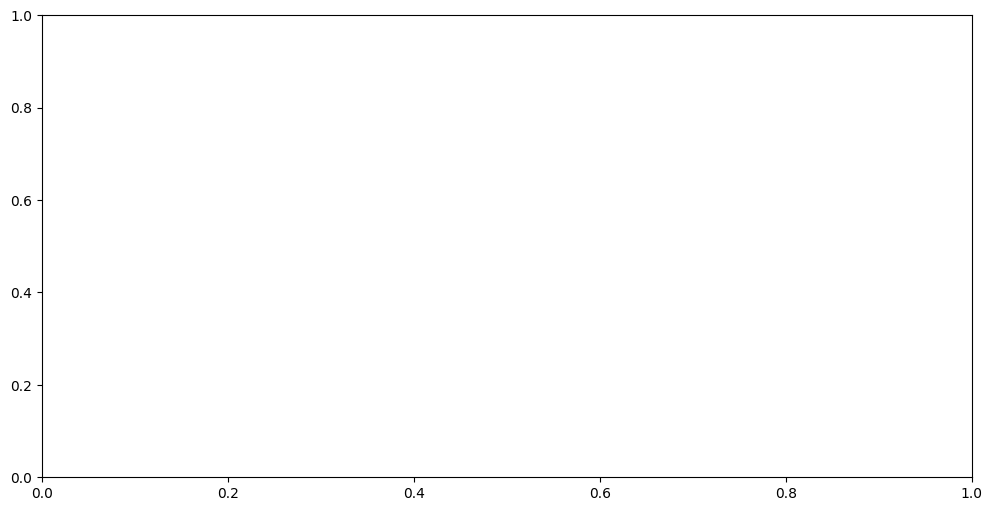

In [ ]:
#극한강수/폭우 시기 분석

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# [전제] 이전 단계에서 만든 'month' 컬럼이 있어야 합니다.
# 만약 없다면: df_virus['month'] = df_virus['week'].dt.month (또는 이전 코드 참고)

# 1) 극한 강수/침수 지표 설정 (예: 침수 면적이 0보다 큰 경우만 추출하거나 상위 10% 정의)
# 여기서는 월별 발생 빈도와 강도를 시각화합니다.

fig, ax1 = plt.subplots(figsize=(12, 6))

# 침수 강도(Intensity) 월별 평균 (막대 그래프)
sns.barplot(data=df_virus, x='month', y='avg_flood_intensity',
            estimator='mean', ax=ax1, palette='Blues', alpha=0.7, label='Avg Flood Intensity')
ax1.set_ylabel('Flood Intensity', color='blue', fontsize=12)

# 침수 면적(Area) 월별 합계 (선 그래프로 겹쳐서 표시)
ax2 = ax1.twinx()
sns.lineplot(data=df_virus, x=df_virus['month']-1, y='sum_flood_area',
             estimator='sum', ax=ax2, color='red', marker='o', label='Total Flood Area')
ax2.set_ylabel('Total Flood Area', color='red', fontsize=12)

plt.title('Monthly Distribution of Extreme Precipitation & Flooding', fontsize=15)
plt.xticks(range(0, 12), [f'{i}M' for i in range(1, 13)])
plt.show()

In [ ]:
#5, 6월, 7월, 8월, 9월,10월 데이터만 추출
df_virus_1 = df_virus[df_virus['month'].isin([ 6, 7, 8, 9])].copy()

In [ ]:
df_virus_1=df_virus.drop(columns=['t','sin52','cos52','sin52_2','cos52_2','nb_residual','nb_residual_pearson','sum_flood_area','avg_flood_intensity'])

KeyError: "['sum_flood_area', 'avg_flood_intensity'] not found in axis"

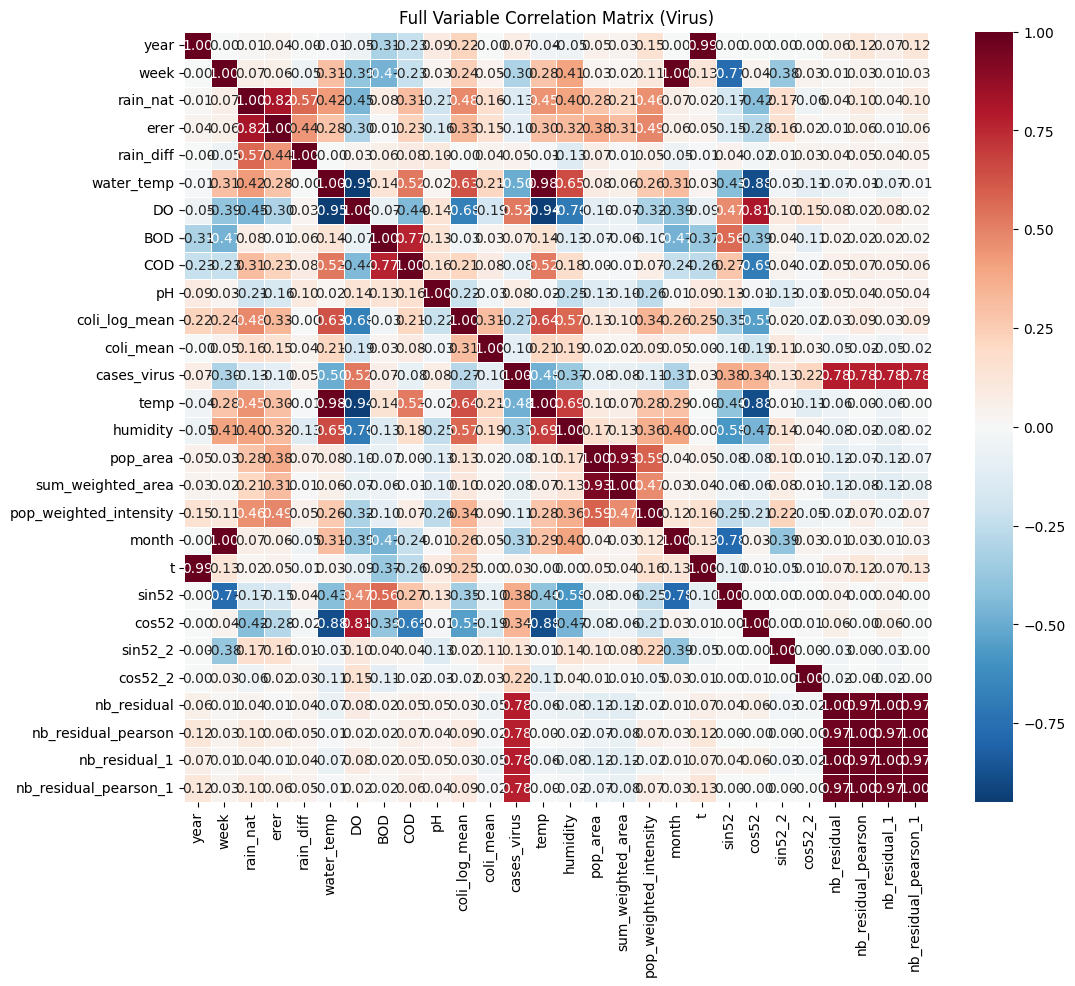

In [ ]:
#상관행렬
import seaborn as sns
import matplotlib.pyplot as plt

# 수치형 변수 전체 선택
all_numeric_cols = df_virus_1.select_dtypes(include=['number']).columns.tolist()

plt.figure(figsize=(12, 10))
corr_matrix = df_virus[all_numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Full Variable Correlation Matrix (Virus)')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import ccf
from scipy.stats import norm

def calculate_ccf_summary(df, target_col, max_lag=8):
    results = []

    # 수치형 변수만 선택 (대상 변수 제외)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    feature_cols = [col for col in numeric_cols if col != target_col]

    n = len(df)

    for col in feature_cols:
        # 두 변수 추출 (결측치는 0으로 처리하거나 제거)
        y = df[target_col].fillna(0).values
        x = df[col].fillna(0).values

        # CCF 계산 (0~max_lag)
        # ccf(y, x)는 x가 y보다 앞서는(lead) 관계를 보여줌
        cc_values = ccf(y, x, adjusted=False)[:max_lag + 1]

        # 절대값 기준으로 가장 상관계수가 높은 lag 찾기
        abs_cc_values = np.abs(cc_values)
        best_lag = np.argmax(abs_cc_values)
        correlation = cc_values[best_lag]

        # p-value 근사치 계산 (표준 오차 이용)
        # 상관계수의 표준오차는 약 1/sqrt(n)
        stderr = 1 / np.sqrt(n)
        z_score = correlation / stderr
        p_value = 2 * (1 - norm.cdf(abs(z_score)))

        results.append({
            'variable': col,
            'best_lag': float(best_lag),
            'correlation': correlation,
            'p_value': p_value
        })

    # 데이터프레임으로 변환 후 p_value 순으로 정렬
    summary_df = pd.DataFrame(results)
    return summary_df.sort_values('p_value').reset_index(drop=True)

# 실행
ccf_resid_summary_df = calculate_ccf_summary(df_virus_1, 'cases_virus')

# 결과 출력
print(ccf_resid_summary_df)

                  variable  best_lag  correlation       p_value
0      nb_residual_pearson       0.0     0.943495  0.000000e+00
1            nb_residual_1       0.0     0.901528  0.000000e+00
2    nb_residual_pearson_1       0.0     0.943597  0.000000e+00
3              nb_residual       0.0     0.901329  0.000000e+00
4                     year       0.0     0.480550  8.088844e-09
5                        t       0.0     0.470641  1.626128e-08
6            coli_log_mean       0.0     0.248358  2.879733e-03
7                    month       0.0    -0.216107  9.506320e-03
8                     week       0.0    -0.214948  9.897945e-03
9                    sin52       0.0     0.181074  2.978919e-02
10                 cos52_2       0.0     0.177468  3.320306e-02
11                   cos52       0.0    -0.176513  3.416164e-02
12                     BOD       8.0    -0.163704  4.947762e-02
13                humidity       1.0    -0.160092  5.471921e-02
14                    temp       4.0    

In [ ]:
rain_nat_ccf = calculate_ccf_summary(df_virus_1, 'cases_virus', max_lag=8)
rain_nat_ccf

,variable,best_lag,correlation,p_value
0,nb_residual_pearson,0.0,0.943495,0.000000e+00
1,nb_residual_1,0.0,0.901528,0.000000e+00
2,nb_residual_pearson_1,0.0,0.943597,0.000000e+00
3,nb_residual,0.0,0.901329,0.000000e+00
4,year,0.0,0.480550,8.088844e-09
5,t,0.0,0.470641,1.626128e-08
6,coli_log_mean,0.0,0.248358,2.879733e-03
7,month,0.0,-0.216107,9.506320e-03
8,week,0.0,-0.214948,9.897945e-03
9,sin52,0.0,0.181074,2.978919e-02


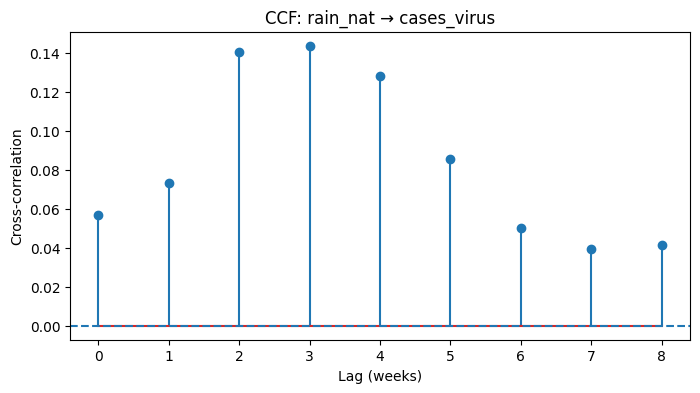

array([0.05691494, 0.07337818, 0.14033504, 0.14363209, 0.12786672,
       0.08535664, 0.05020841, 0.03958399, 0.04121419])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf

def compute_ccf(df, x_col, y_col='cases_virus', max_lag=8):

    x = df[x_col].values
    y = df[y_col].values

    # 결측 제거
    valid = (~np.isnan(x)) & (~np.isnan(y))
    x = x[valid]
    y = y[valid]

    # 표준화 (권장)
    x = (x - np.mean(x)) / np.std(x)
    y = (y - np.mean(y)) / np.std(y)

    ccf_vals = ccf(x, y)[:max_lag+1]
    lags = np.arange(0, max_lag+1)

    plt.figure(figsize=(8,4))
    plt.stem(lags, ccf_vals)
    plt.xlabel("Lag (weeks)")
    plt.ylabel("Cross-correlation")
    plt.title(f"CCF: {x_col} → {y_col}")
    plt.axhline(0, linestyle='--')
    plt.show()

    return ccf_vals


ccf_rain_nat = compute_ccf(df_virus_1, 'rain_nat', max_lag=8)
ccf_rain_nat

#극한 강수/ 폭우 시에 바깥 활동량이 줄어듦.
#그러나 노로바이러스는 사람사이의 감염이 심하다보니 이런 효과가 나타나는 것일수도.
#또는 여름철

# **3-3) 바이러스성 질병 머신러닝 모델링.**

In [ ]:
df_virus.columns

Index(['year', 'week', 'rain_nat', 'erer', 'rain_diff', 'water_temp', 'DO',
       'BOD', 'COD', 'pH', 'coli_log_mean', 'coli_mean', 'cases_virus', 'temp',
       'humidity', 'pop_area', 'sum_weighted_area', 'pop_weighted_intensity',
       'month', 't', 'sin52', 'cos52', 'sin52_2', 'cos52_2', 'nb_residual',
       'nb_residual_pearson', 'nb_residual_1', 'nb_residual_pearson_1'],
      dtype='object')

In [ ]:
df_0=df_virus.copy()
df_1=df_virus.copy()

1. 해석용 머신러닝 모델. - 자기 상관 통제.

In [ ]:
#df 변수 제거
#온도와 계절성을 모두 통제하고 있으므로 온도와 계절변수 제거

df_0=df_0.drop(columns=['coli_mean','t','sin52','cos52','sin52_2','cos52_2','pop_weighted_intensity','water_temp','water_temp','temp','nb_residual_1','nb_residual','nb_residual_pearson_1','cases_virus'])


In [ ]:
df_0.columns

Index(['year', 'week', 'rain_nat', 'erer', 'rain_diff', 'DO', 'BOD', 'COD',
       'pH', 'coli_log_mean', 'humidity', 'pop_area', 'sum_weighted_area',
       'month', 'nb_residual_pearson'],
      dtype='object')

In [ ]:
#지연 상관 변수 생성 및 자기 상관 구조 통제
#지연은 아래와 같음
#강수지표: 0
#침수지표: 5
#수질지표: 1
#환경지표: 1

import pandas as pd

df_0 = df_0.sort_values(['year', 'week']).reset_index(drop=True)

# (1) 잔차 lag1 (AR 통제용)
df_0['nb_residual_pearson_lag1'] = df_0['nb_residual_pearson'].shift(1)

# (2) 수질 변수 lag1
water_vars = ['DO', 'BOD', 'COD', 'pH', 'coli_log_mean']
for var in water_vars:
    df_0[f'{var}_lag1'] = df_0[var].shift(1)

# (3) 습도 lag1
df_0['humidity_lag1'] = df_0['humidity'].shift(1)

# (4) 침수 변수 lag5
flood_vars = ['pop_area', 'sum_weighted_area']
for var in flood_vars:
    df_0[f'{var}_lag5'] = df_0[var].shift(5)


cols_to_drop = (
    water_vars +
    ['humidity'] +
    flood_vars
)

df_model = df_0.drop(columns=cols_to_drop)


df_model = df_model.dropna().reset_index(drop=True)


print(df_model.columns)


Index(['year', 'week', 'rain_nat', 'erer', 'rain_diff', 'month',
       'nb_residual_pearson', 'nb_residual_pearson_lag1', 'DO_lag1',
       'BOD_lag1', 'COD_lag1', 'pH_lag1', 'coli_log_mean_lag1',
       'humidity_lag1', 'pop_area_lag5', 'sum_weighted_area_lag5'],
      dtype='object')


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


In [ ]:
#time series train/test data split

# target
y = df_model['nb_residual_pearson']

# feature (year, week 제외)
X = df_model.drop(columns=['nb_residual_pearson', 'year', 'week'])

tscv = TimeSeriesSplit(n_splits=5)

# 마지막 split을 test로 사용
for train_idx, test_idx in tscv.split(X):
    pass

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (345, 13)
Test size: (68, 13)


In [ ]:
#random forest

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("RF RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))


RF RMSE: 0.433645855059862


In [ ]:
#random forest tuning
rf_param = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 5, 8, 12],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param,
    n_iter=20,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_

rf_pred = rf_best.predict(X_test)
print("RF Tuned RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))


RF Tuned RMSE: 0.46157717327146874


In [ ]:
#xgboost
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("XGB RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))


XGB RMSE: 0.5069885968071143


In [ ]:
#xgboost tuning
xgb_param = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    xgb_param,
    n_iter=20,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)
xgb_best = xgb_search.best_estimator_

xgb_pred = xgb_best.predict(X_test)
print("XGB Tuned RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))

#tune 전 rmse 가 더 높음

XGB Tuned RMSE: 0.44488551402247367


In [ ]:
lgb = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb.fit(X_train, y_train)
lgb_pred = lgb.predict(X_test)

print("LGBM RMSE:", np.sqrt(mean_squared_error(y_test, lgb_pred)))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1102
[LightGBM] [Info] Number of data points in the train set: 345, number of used features: 12
[LightGBM] [Info] Start training from score -0.037960
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [ ]:
#lgb tuning
lgb_param = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 63],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

lgb_search = RandomizedSearchCV(
    LGBMRegressor(random_state=42),
    lgb_param,
    n_iter=20,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

lgb_search.fit(X_train, y_train)
lgb_best = lgb_search.best_estimator_

lgb_pred = lgb_best.predict(X_test)
print("LGBM Tuned RMSE:", np.sqrt(mean_squared_error(y_test, lgb_pred)))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000076 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1102
[LightGBM] [Info] Number of data points in the train set: 345, number of used features: 12
[LightGBM] [Info] Start training from score -0.037960
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [ ]:
results = {
    "RF": np.sqrt(mean_squared_error(y_test, rf_pred)),
    "XGB": np.sqrt(mean_squared_error(y_test, xgb_pred)),
    "LGBM": np.sqrt(mean_squared_error(y_test, lgb_pred))
}

print(results)


#lgbm이 가장 낮은 좋은 성능.
#해당 모델은 예측력이 낮게 나올 수 밖에 없음. 다만 해석을 위함.

{'RF': np.float64(0.433645855059862), 'XGB': np.float64(0.5069885968071143), 'LGBM': np.float64(0.5775415078008811)}


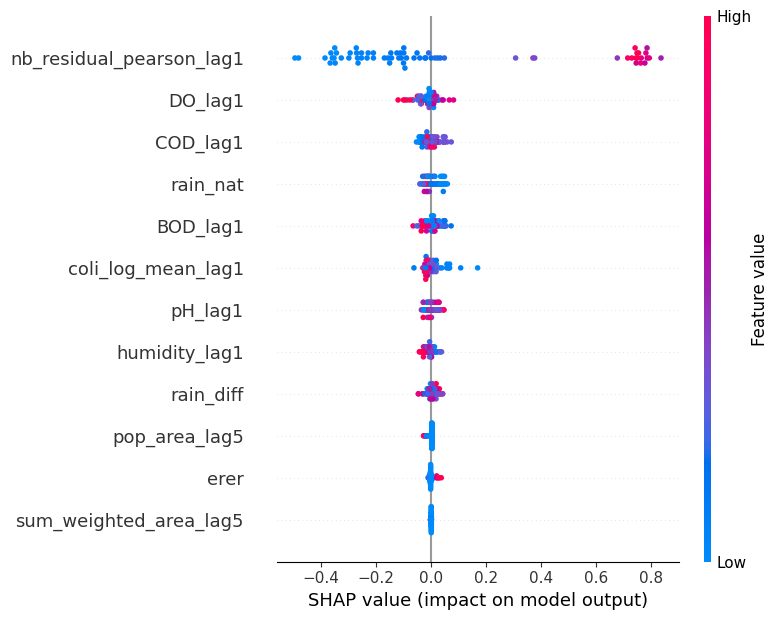

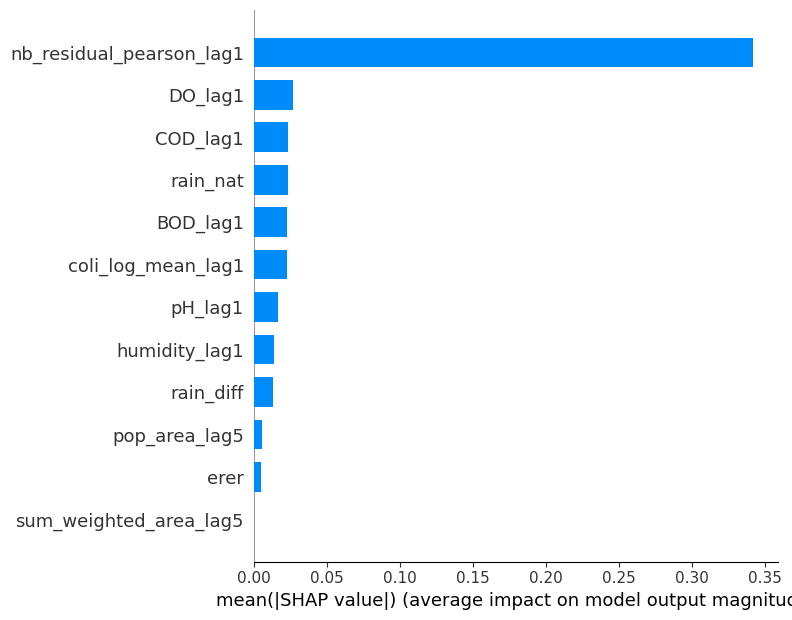

In [ ]:
#변수 영향력 해석
import shap

# best 모델 사용
model = lgb

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 1️⃣ 전체 중요도 요약
shap.summary_plot(shap_values, X_test)

# 2️⃣ 강수 변수만 보고 싶다면
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)


#예측에 강수 변수는 큰 영향을 주지 못하는 것으로 분석됨.

In [ ]:
#시간 나면 추가로 nb_residual_lag 빼고 다시 모델 구동.

1.1) 자기 상관 변수 제거한 상태로.

In [ ]:
df_s=df_0.copy()

In [ ]:
df_s.columns

Index(['year', 'week', 'rain_nat', 'erer', 'rain_diff', 'DO', 'BOD', 'COD',
       'pH', 'coli_log_mean', 'humidity', 'pop_area', 'sum_weighted_area',
       'month', 'nb_residual_pearson', 'nb_residual_pearson_lag1', 'DO_lag1',
       'BOD_lag1', 'COD_lag1', 'pH_lag1', 'coli_log_mean_lag1',
       'humidity_lag1', 'pop_area_lag5', 'sum_weighted_area_lag5'],
      dtype='object')

In [ ]:
df_s=df_s.drop(columns='nb_residual_pearson_lag1')

In [ ]:
#time series train/test data split

# target
y = df_s['nb_residual_pearson']

# feature (year, week 제외)
X = df_s.drop(columns=['nb_residual_pearson', 'year', 'week'])

tscv = TimeSeriesSplit(n_splits=5)

# 마지막 split을 test로 사용
for train_idx, test_idx in tscv.split(X):
    pass

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (349, 20)
Test size: (69, 20)


In [ ]:
#random forest

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("RF RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))


RF RMSE: 1.0206538257193014


In [ ]:
#xgboost
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("XGB RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))


XGB RMSE: 1.0240987098257208


In [ ]:
lgb = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb.fit(X_train, y_train)
lgb_pred = lgb.predict(X_test)

print("LGBM RMSE:", np.sqrt(mean_squared_error(y_test, lgb_pred)))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1750
[LightGBM] [Info] Number of data points in the train set: 349, number of used features: 20
[LightGBM] [Info] Start training from score -0.043455
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [ ]:
results = {
    "RF": np.sqrt(mean_squared_error(y_test, rf_pred)),
    "XGB": np.sqrt(mean_squared_error(y_test, xgb_pred)),
    "LGBM": np.sqrt(mean_squared_error(y_test, lgb_pred))
}

print(results)


#lgbm이 가장 낮은 좋은 성능.
#해당 모델은 예측력이 낮게 나올 수 밖에 없음. 다만 해석을 위함.

#자기상관 통제 변수 제거했을 때 성능 개선

{'RF': np.float64(1.0206538257193014), 'XGB': np.float64(1.0240987098257208), 'LGBM': np.float64(1.0383691984427141)}


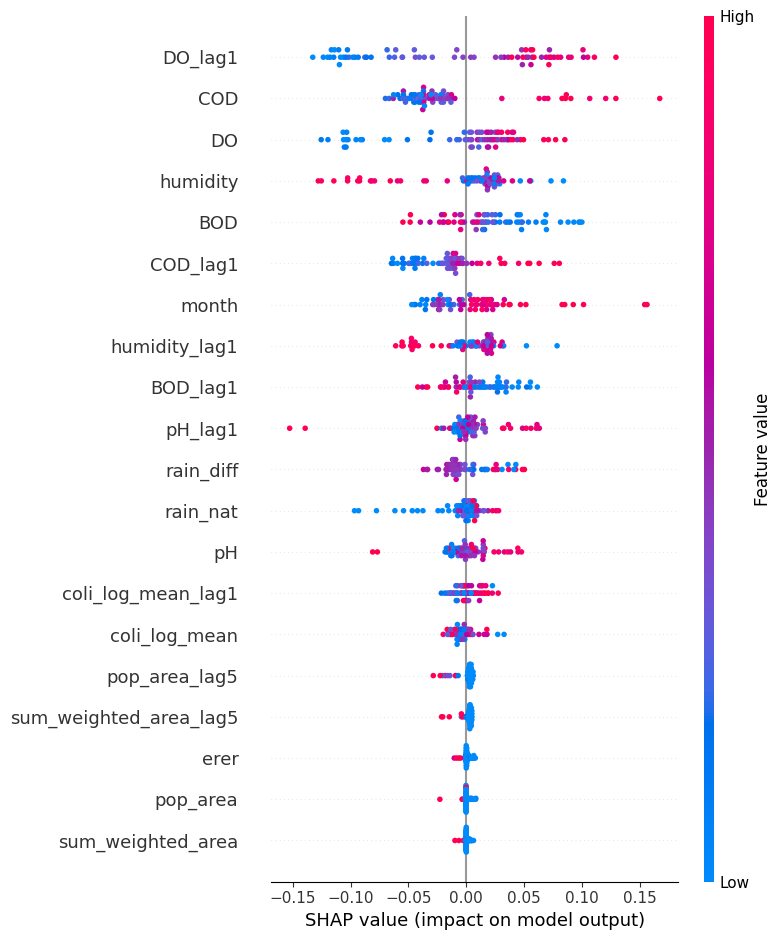

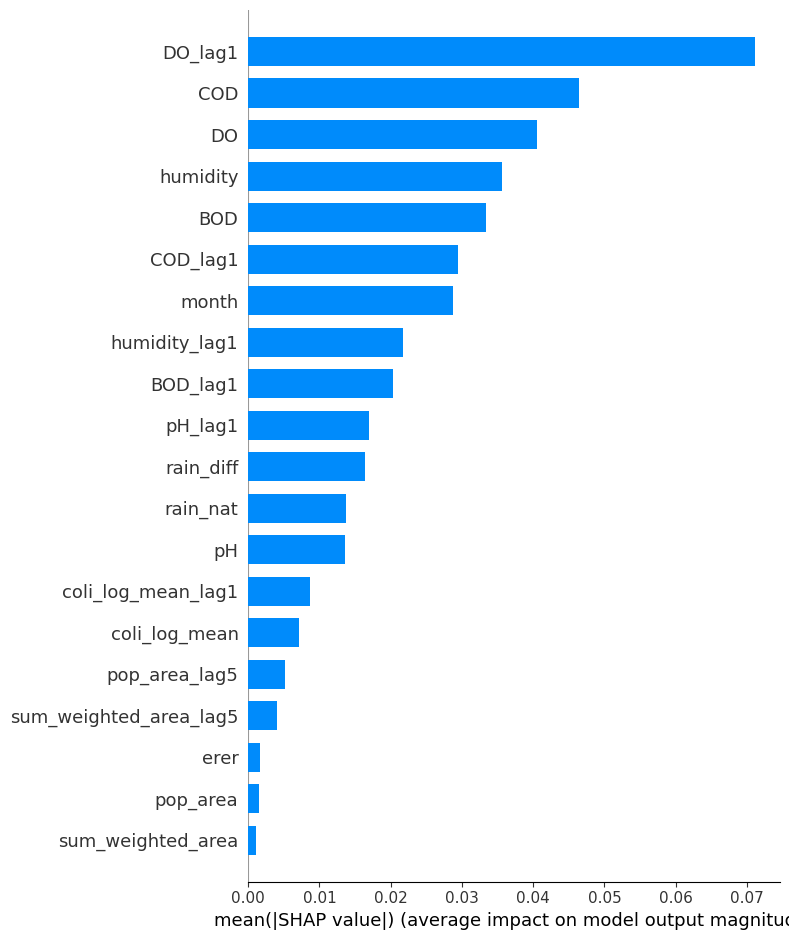

In [ ]:
#변수 영향력 해석
import shap

# best 모델 사용
model = rf

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 1️⃣ 전체 중요도 요약
shap.summary_plot(shap_values, X_test)

# 2️⃣ 강수 변수만 보고 싶다면
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)


#여전히 강수 변수는 큰 영향을 주지 못하는 것으로 분석됨.
#수질 지표들이 더 중요한 역할을함.

2. 예측용 머신러닝 모델.

In [ ]:
#df에서 변수 제거
df_1=df_1.drop(columns=['coli_mean','avg_flood_intensity','Unnamed: 0','pop_weighted_intensity','sum_flood_area','nb_residual_1','nb_residual','nb_residual_pearson_1','nb_residual_pearson'])


In [ ]:
df_1.columns

Index(['year', 'week', 'rain_nat', 'erer', 'rain_diff', 'water_temp', 'DO',
       'BOD', 'COD', 'pH', 'coli_log_mean', 'cases_virus', 'temp', 'humidity',
       'pop_area', 'sum_weighted_area', 't', 'sin52', 'cos52', 'sin52_2',
       'cos52_2'],
      dtype='object')

In [ ]:
import pandas as pd

df_ml = df_1.copy()

# -------------------------
# 1. Lag 생성
# -------------------------

# 강수지표 (lag0 → 그대로 사용)
# rain_nat 그대로 둠

# 침수지표 lag5
df_ml['pop_area_lag5'] = df_ml['pop_area'].shift(5)
df_ml['sum_weighted_area_lag5'] = df_ml['sum_weighted_area'].shift(5)

# 수질
df_ml['DO_lag1'] = df_ml['DO'].shift(1)
df_ml['COD_lag1'] = df_ml['COD'].shift(1)
df_ml['BOD_lag1'] = df_ml['BOD'].shift(1)
df_ml['pH_lag1'] = df_ml['pH'].shift(1)
df_ml['coli_lag5'] = df_ml['coli_log_mean'].shift(5)

# 환경
df_ml['temp_lag3'] = df_ml['temp'].shift(3)
df_ml['humidity_lag2'] = df_ml['humidity'].shift(2)

# -------------------------
# 2. 기존 변수 제거
# -------------------------

drop_cols = [
    'pop_area', 'sum_weighted_area',
    'DO', 'coli_log_mean',
    'temp', 'humidity',
    'COD','BOD','pH'
]

df_ml = df_ml.drop(columns=drop_cols)

# lag로 인한 결측 제거
df_ml = df_ml.dropna().reset_index(drop=True)


In [ ]:
df_ml.columns

Index(['year', 'week', 'rain_nat', 'erer', 'rain_diff', 'water_temp',
       'cases_virus', 't', 'sin52', 'cos52', 'sin52_2', 'cos52_2',
       'pop_area_lag5', 'sum_weighted_area_lag5', 'DO_lag1', 'COD_lag1',
       'BOD_lag1', 'pH_lag1', 'coli_lag5', 'temp_lag3', 'humidity_lag2'],
      dtype='object')

In [ ]:
df_ml=df_ml.drop(columns='water_temp')

In [ ]:
y = df_ml['cases_virus']

X = df_ml.drop(columns=[
    'cases_virus',
    'year', 'week'
])


In [ ]:
split_index = int(len(df_ml) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

from sklearn.metrics import r2_score
r2 = r2_score(y_test, rf_pred)

print("R-squared:", r2)
print("RF RMSE:", rf_rmse)

R-squared: -0.438906752370396
RF RMSE: 115.75091637138303


t                         0.391759
DO_lag1                   0.344686
temp_lag3                 0.166205
sin52                     0.020966
COD_lag1                  0.010997
humidity_lag2             0.009755
BOD_lag1                  0.008413
coli_lag5                 0.007420
rain_diff                 0.007382
cos52                     0.007178
cos52_2                   0.005968
sin52_2                   0.005807
rain_nat                  0.005675
pH_lag1                   0.005501
erer                      0.002051
pop_area_lag5             0.000126
sum_weighted_area_lag5    0.000112
dtype: float64


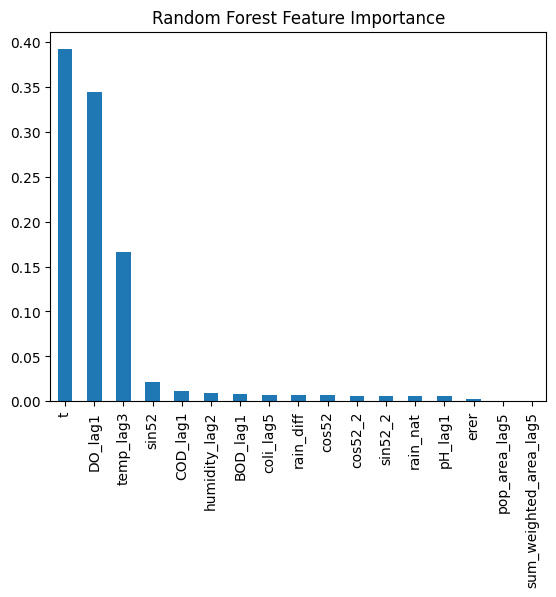

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(rf_importance)

# 시각화
rf_importance.plot(kind='bar')
plt.title("Random Forest Feature Importance")
plt.show()


In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
r2 = r2_score(y_test, xgb_pred)

print("R-squared:", r2)
print("XGB RMSE:", xgb_rmse)


R-squared: -0.17507529258728027
XGB RMSE: 104.60223206569256


DO_lag1                   0.350994
temp_lag3                 0.218842
t                         0.177439
sin52                     0.053917
cos52                     0.053576
humidity_lag2             0.024206
COD_lag1                  0.021417
coli_lag5                 0.016346
BOD_lag1                  0.016145
sin52_2                   0.015427
pH_lag1                   0.012765
rain_diff                 0.008664
cos52_2                   0.007377
sum_weighted_area_lag5    0.006837
erer                      0.006436
rain_nat                  0.005847
pop_area_lag5             0.003768
dtype: float32


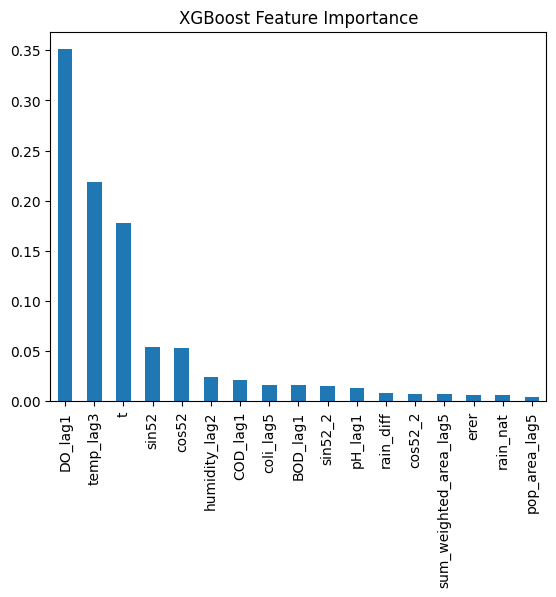

In [ ]:
xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(xgb_importance)

xgb_importance.plot(kind='bar')
plt.title("XGBoost Feature Importance")
plt.show()


In [ ]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm.fit(X_train, y_train)

lgbm_pred = lgbm.predict(X_test)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_pred))

r2 = r2_score(y_test, lgbm_pred)

print("R-squared:", r2)
print("LGBM RMSE:", lgbm_rmse)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000108 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1500
[LightGBM] [Info] Number of data points in the train set: 330, number of used features: 17
[LightGBM] [Info] Start training from score 157.700000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

t                         662
coli_lag5                 636
humidity_lag2             626
temp_lag3                 622
DO_lag1                   581
pH_lag1                   434
COD_lag1                  340
BOD_lag1                  337
rain_diff                 322
sin52_2                   321
rain_nat                  311
cos52                     283
sin52                     240
cos52_2                   168
erer                       90
pop_area_lag5              13
sum_weighted_area_lag5      6
dtype: int32


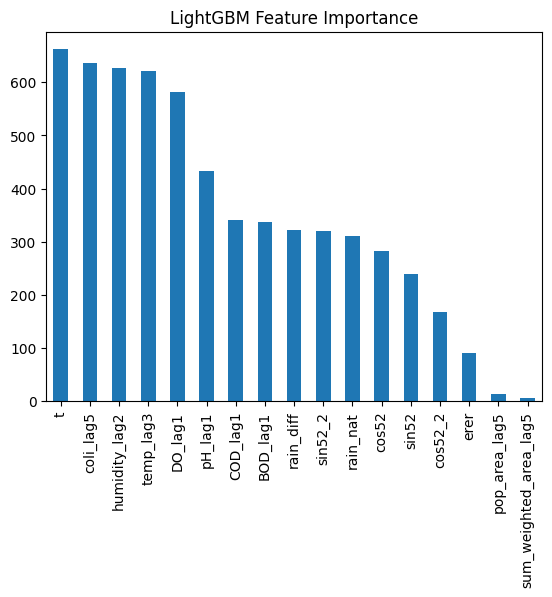

In [ ]:
lgbm_importance = pd.Series(
    lgbm.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(lgbm_importance)

lgbm_importance.plot(kind='bar')
plt.title("LightGBM Feature Importance")
plt.show()


In [ ]:
#rf의 성능이 가장 좋은 것으로 판단됨

#더불어 바이러스 질병 예측에는 수질지표, 온도/습도, 계절성 지표들이 중요한 역할을 하는 것으로 보임.
#강수량 지표들은 큰 영향력이 없음.


In [ ]:
#계절성 통제하였을 때 shap 영향력 분석

import shap

# TreeExplainer 생성
explainer = shap.TreeExplainer(rf)

# shap 값 계산
shap_values = explainer.shap_values(X_test)


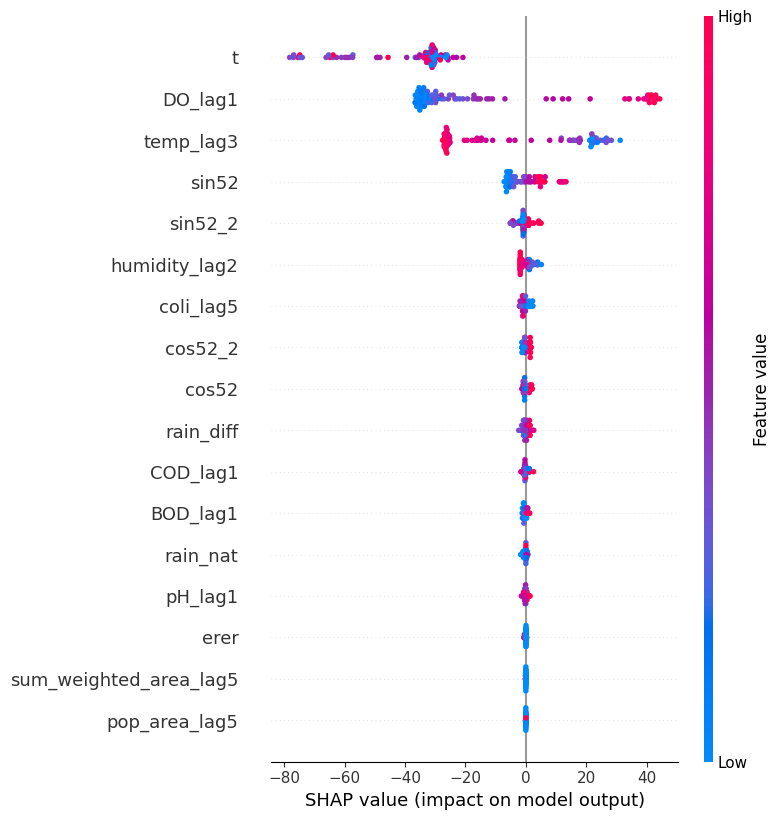

In [ ]:
shap.summary_plot(shap_values, X_test)


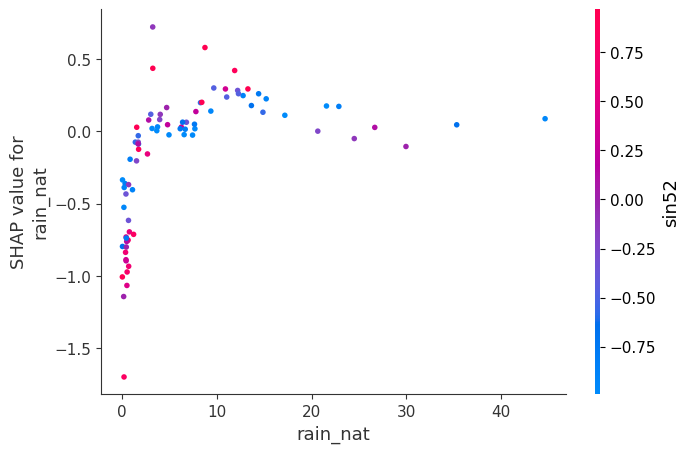

In [ ]:
shap.dependence_plot(
    "rain_nat",
    shap_values,
    X_test
)

#강수량이 적을 때 강수 변수는 예측값을 감소 방향으로 기여
#즉, 건조한 조건에서는 감염 증가 요인이 아님.
#강수량이 조금 커질 때 감염 증가에 기여
#그러나 강수량 20mm이상일 때 다시 shap값0으로 수렴